<a href="https://colab.research.google.com/github/5tevenZhang/Quant-Project/blob/main/News_Driven_Stock_Return_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import zipfile
import pytz
import re
import random
from datetime import datetime
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# Set all random seeds (ensure reproducibility)
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Initialize NLTK tools (for text preprocessing)
import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Data loading and preprocessing
def read_tsv_from_zip(zip_path, sort=True):
    """
    Read all TSV files inside a ZIP archive and return a dictionary (filename -> DataFrame)
    """
    data_frames = {}
    with zipfile.ZipFile(zip_path, 'r') as z:
        # Get all files and filter for .tsv files (case-insensitive)
        tsv_files = [f for f in z.namelist() if f.lower().endswith('.tsv')]
        if sort:
            tsv_files.sort()  # Sort by filename

        for filename in tsv_files:
            with z.open(filename) as file:
                # Read TSV using pandas (tab-separated)
                df = pd.read_csv(file, sep='\t')
                data_frames[filename] = df
    return data_frames

def data_load(zip_path, price_file, news_file):
    # Price data
    test_data = read_tsv_from_zip(zip_path)
    price_df = test_data[price_file]
    price_df['date'] = pd.to_datetime(price_df['date'])
    price_df['date'] = price_df['date'].dt.date
    # News data
    news_df = []
    for n_file in news_files:
        news_df.append(test_data[n_file])
    news_df = pd.concat(news_df, axis=0)
    news_df['timestamp'] = pd.to_datetime(news_df['timestamp'])
    news_df['date'] = news_df['timestamp'].dt.date
    news_df['time'] = news_df['timestamp'].dt.time
    news_df['full_text'] = news_df['headline'].fillna('') + ' ' + news_df['body'].fillna('')
    return news_df, price_df

# Data preprocessing module
def filter_overnight_news(news_df: pd.DataFrame, price_df: pd.DataFrame) -> pd.DataFrame:
    """Filter overnight news from 16:00 of the previous trading day to 9:30 of the current day (NYC time)"""
    # 1. Get the trading calendar (extracted from stock price data, excluding non-trading days)
    trading_dates = sorted(set(price_df['date'].tolist()))
    date_to_prev_trading_date = {trading_dates[i]: trading_dates[i - 1] for i in range(1, len(trading_dates))}

    # 2. Define NYSE trading time boundaries
    open_time = pd.Timestamp('09:30:00').time()
    close_time = pd.Timestamp('16:00:00').time()

    # 3. Filter overnight news
    overnight_news = []
    for _, row in news_df.iterrows():
        curr_date = row['date']
        if curr_date not in date_to_prev_trading_date:  # Exclude the first trading day (no previous trading day)
            continue

        prev_trading_date = date_to_prev_trading_date[curr_date]
        # Overnight news condition: after previous trading day's close or before current day's open
        is_overnight = (
                (row['date'] == prev_trading_date and row['time'] >= close_time) or
                (row['date'] == curr_date and row['time'] <= open_time)
        )

        if is_overnight:
            row['prediction_date'] = curr_date  # Prediction trading day corresponding to the news
            overnight_news.append(row)

    # Deduplicate (remove duplicate headlines)
    return pd.DataFrame(overnight_news).drop_duplicates(subset=['headline'])


def prepare_target_and_align(price_df: pd.DataFrame, overnight_news_df: pd.DataFrame) -> pd.DataFrame:
    """Compute target variables (open-to-close return) and align news with price data by symbol + prediction trading day"""
    # 1. Compute regression target (continuous value) and classification target (up/down label)
    price_df['target_reg'] = (price_df['close'] - price_df['open']) / price_df['open']
    price_df['target_cls'] = (price_df['target_reg'] > 0).astype(int)  # 1=up, 0=down

    # 2. Merge all news headlines for the same ticker-trading day (one sample corresponds to one text)
    news_grouped = overnight_news_df.groupby(['symbol', 'prediction_date'])['full_text'].apply(
        lambda x: ' '.join(x)  # Merge multiple pieces of news into one text
    ).reset_index()
    news_grouped.rename(columns={'prediction_date': 'date'}, inplace=True)  # Align with price date

    # 3. Align news and price data (keep only samples with overnight news)
    aligned_df = pd.merge(
        news_grouped, price_df[['symbol', 'date', 'target_reg', 'target_cls']],
        on=['symbol', 'date'],
        how='inner'
    )
    aligned_df = aligned_df.sort_values(['date', 'symbol'], ascending=True).reset_index(drop=True)
    return aligned_df


# Feature engineering
def preprocess_text(text: str) -> str:
    """Text cleaning: lowercase → remove punctuation → remove stopwords → stemming"""
    text = text.lower()  # Lowercase
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    words = [stemmer.stem(word) for word in text.split() if word not in stop_words]  # Remove stopwords + stemming
    return ' '.join(words)


def generate_text_features(aligned_df: pd.DataFrame, feature_type: str = 'tfidf') -> tuple[np.ndarray, object]:
    """Generate only BoW or TF-IDF features (no auxiliary features), with fixed parameters to ensure reproducibility"""
    # 1. Preprocess all text
    aligned_df['cleaned_text'] = aligned_df['full_text'].apply(preprocess_text)

    # 2. Fix text feature parameters (key: ensure reproducibility)
    vectorizer_params = {
        'max_features': 100,  # Keep the top 100 high-frequency words (control dimensionality)
        'ngram_range': (1, 2),  # Unigrams + bigrams (capture phrases like “stock offering”)
        'stop_words': 'english',  # Remove stopwords twice
        'lowercase': False  # Already lowercased earlier, avoid repeated processing
    }

    # 3. Initialize vectorizer and generate features
    if feature_type == 'bow':
        vectorizer = CountVectorizer(**vectorizer_params)
    elif feature_type == 'tfidf':
        vectorizer = TfidfVectorizer(**vectorizer_params)
    else:
        raise ValueError("feature_type must be 'bow' or 'tfidf'")

    # Generate text feature matrix (sparse matrix, directly used for modeling)
    text_features = vectorizer.fit_transform(aligned_df['cleaned_text'])

    return text_features, vectorizer, aligned_df[['target_reg', 'target_cls']]  # Return features + vectorizer + targets


# Train-test split
def split_time_series(aligned_df: pd.DataFrame, features: np.ndarray, targets: pd.DataFrame,
                      train_ratio: float = 0.75) -> tuple:
    """Split training/test sets by time order (no random split, to avoid future data leakage)"""
    aligned_df_sorted = aligned_df.reset_index(drop=True)
    features_sorted = features[aligned_df_sorted.index]  # Synchronize feature order
    targets_sorted = targets.iloc[aligned_df_sorted.index]  # Synchronize target order
    # Compute split point (first 75% as training set, last 25% as test set)
    split_idx = int(len(aligned_df_sorted) * train_ratio)

    # Split training/test sets
    X_train, X_test = features_sorted[:split_idx], features_sorted[split_idx:]
    y_reg_train, y_reg_test = targets_sorted['target_reg'][:split_idx], targets_sorted['target_reg'][split_idx:]
    y_cls_train, y_cls_test = targets_sorted['target_cls'][:split_idx], targets_sorted['target_cls'][split_idx:]

    print(f"Training set sample size: {X_train.shape[0]}, feature dimension: {X_train.shape[1]}")
    print(f"Test set sample size: {X_test.shape[0]}, feature dimension: {X_test.shape[1]}")
    return X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test

# Model and hyperparameter tuning
def tune_model_with_text_features(model_type: str, X_train: np.ndarray, y_train: np.ndarray) -> tuple[
    dict, pd.DataFrame]:
    """Tune models using only text features, with TimeSeriesSplit to avoid data leakage"""
    tscv = TimeSeriesSplit(n_splits=5)  # Time-based cross-validation (5 folds)
    best_params = {}
    cv_results = None

    # 1. Ridge regression (regression task, optimize alpha)
    if model_type == 'ridge_reg':
        from sklearn.linear_model import Ridge
        model = Ridge(random_state=SEED, solver='auto')
        param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}  # Regularization strength
        grid_search = GridSearchCV(
            estimator=model, param_grid=param_grid, cv=tscv,
            scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1
        )
        grid_search.fit(X_train, y_train)
        best_params = grid_search.best_params_
        cv_results = pd.DataFrame(grid_search.cv_results_)[['param_alpha', 'mean_test_score']]
        cv_results['mean_test_score'] = -cv_results['mean_test_score']  # Convert to MAE (positive value)
        cv_results.columns = ['alpha', 'mean_mae']

    # 2. Random forest regression (optimize n_estimators + max_depth)
    elif model_type == 'rf_reg':
        model = RandomForestRegressor(random_state=SEED, bootstrap=True)
        param_grid = {
            'n_estimators': [50, 100, 200],  # Number of trees
            'max_depth': [3, 5, 10]  # Tree depth (prevent overfitting)
        }
        grid_search = GridSearchCV(
            estimator=model, param_grid=param_grid, cv=tscv,
            scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1  # Use MAE as tuning metric
        )
        grid_search.fit(X_train, y_train)
        best_params = grid_search.best_params_
        cv_results = pd.DataFrame(grid_search.cv_results_)[['param_n_estimators', 'param_max_depth', 'mean_test_score']]
        cv_results['mean_test_score'] = -cv_results['mean_test_score']  # Convert to MAE (positive value)
        cv_results.columns = ['n_estimators', 'max_depth', 'mean_mae']

    # 3. XGBoost regression (regression task, optimize learning_rate + max_depth)
    elif model_type == 'xgb_reg':
        from xgboost import XGBRegressor
        model = XGBRegressor(seed=SEED, subsample=0.8, colsample_bytree=0.8, objective='reg:squarederror')
        param_grid = {
            'learning_rate': [0.01, 0.1, 0.2],  # Learning rate
            'max_depth': [3, 5, 10],  # Tree depth
            'n_estimators': [50, 100, 200]  # Number of trees
        }
        grid_search = GridSearchCV(
            estimator=model, param_grid=param_grid, cv=tscv,
            scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1
        )
        grid_search.fit(X_train, y_train)
        best_params = grid_search.best_params_
        cv_results = pd.DataFrame(grid_search.cv_results_)[
            ['param_learning_rate', 'param_max_depth', 'param_n_estimators', 'mean_test_score']
        ]
        cv_results['mean_test_score'] = -cv_results['mean_test_score']  # Convert to MAE
        cv_results.columns = ['learning_rate', 'max_depth', 'n_estimators', 'mean_mae']

    print(f"{model_type} best parameters: {best_params}")
    return best_params, cv_results

# Model training and evaluation
def stratify_by_return(y_values: np.ndarray, threshold1: float = -0.05, threshold2: float = 0.05) -> np.ndarray:
    """
    Group by return (change rate) using ±5%
    :return: Stratification label array (-1/0/1)
    """
    stratify_labels = np.zeros_like(y_values, dtype=int)
    stratify_labels[y_values < threshold1] = -1  # Less than -5% → -1
    stratify_labels[y_values > threshold2] = 1    # Greater than 5% → 1
    # Between -5% and 5% → 0 (default)
    return stratify_labels

def analyze_stratified_performance(y_true: np.ndarray, y_pred: np.ndarray, threshold1: float, threshold2: float, model_name: str) -> pd.DataFrame:
    """
    Analyze performance after stratification: summarize the actual return distribution corresponding to each predicted stratum
    """
    # 1. Stratify predictions and true values
    pred_strat = stratify_by_return(y_pred, threshold1, threshold2)
    true_strat = stratify_by_return(y_true, threshold1, threshold2)

    # 2. Build stratification result DataFrame
    strat_df = pd.DataFrame({
        'pred_strat': pred_strat,
        'true_strat': true_strat,
        'true_return': y_true,
        'pred_return': y_pred
    })

    # 3. Group statistics by predicted stratum
    strat_stats = []
    for strat_label in [-1, 0, 1]:
        group = strat_df[strat_df['pred_strat'] == strat_label]
        if len(group) == 0:
            continue
        # Compute core metrics
        stats = {
            'model': model_name,
            #'pred_strat': strat_label,  # Predicted stratum (-1/0/1)
            'split_by'+str(threshold1)+'&'+str(threshold2): strat_label,  # Predicted stratum (-1/0/1)
            'sample_count': len(group),  # Number of samples in this stratum
            'sample_ratio': len(group) / len(strat_df),  # Sample proportion
            'true_return_mean': group['true_return'].mean(),  # Mean actual return
            'true_return_median': group['true_return'].median(),  # Median actual return
            'true_strat_-1': (group['true_strat'] == -1).sum() / len(group),  # Proportion with actual stratum -1
            'true_strat_0': (group['true_strat'] == 0).sum() / len(group),  # Proportion with actual stratum 0
            'true_strat_1': (group['true_strat'] == 1).sum() / len(group)  # Proportion with actual stratum 1
        }
        strat_stats.append(stats)

    # 4. Convert to DataFrame and format
    strat_stats_df = pd.DataFrame(strat_stats)
    # Percentage formatting
    for col in ['sample_ratio', 'true_strat_-1', 'true_strat_0', 'true_strat_1']:
        strat_stats_df[col] = strat_stats_df[col].apply(lambda x: f"{x:.2%}")
    # Return formatting (keep 4 decimal places)
    for col in ['true_return_mean', 'true_return_median']:
        strat_stats_df[col] = strat_stats_df[col].apply(lambda x: f"{x:.4f}")

    return strat_stats_df


def cal_sign_return(y_true: np.ndarray, y_pred: np.ndarray, threshold1: float, threshold2: float):
    """
    Construct trading signals based on predictions, and compute the average return of the trading signals and direct short-selling signal
    """
    trade_sign = stratify_by_return(y_pred, threshold1, threshold2)
    trade_return = y_true*trade_sign
    return [-np.mean(y_true), np.mean(trade_return)]


def train_and_evaluate_best_model(model_type: str, best_params: dict, X_train, X_test, y_train, y_test,threshold1,threshold2) -> dict:
    """Train the model with tuned best parameters and evaluate test set performance"""
    results = {}

    # 1. Ridge regression (regression task)
    if model_type == 'ridge_reg':
        model = Ridge(random_state=SEED, solver='auto', **best_params)
        model.fit(X_train, y_train)
        #y_pred = model.predict(X_test)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        train_result = np.stack((np.array(y_train), y_pred_train), axis=1)
        test_result = np.stack((np.array(y_test), y_pred_test), axis=1)

        train_perform = analyze_stratified_performance(train_result[:, 0], train_result[:, 1],
                                                      threshold1, threshold2, model_name='ridge_train')

        test_perform = analyze_stratified_performance(test_result[:, 0], test_result[:, 1],
                                                      threshold1, threshold2, model_name='ridge_test')

        sign_return = pd.DataFrame({
                                    'train_period': cal_sign_return(train_result[:, 0], train_result[:, 1], threshold1, threshold2),
                                    'test_period': cal_sign_return(test_result[:, 0], test_result[:, 1], threshold1, threshold2),
                                    })
        sign_return.index = ['sell_only', 'model_trade']
        sign_return = sign_return.T

        results = {
            'model': model,
            'mae': mean_absolute_error(y_test, y_pred_test),
            'mse': mean_squared_error(y_test, y_pred_test),
            'r2': r2_score(y_test, y_pred_test),
            'train_result': train_result,
            'test_result': test_result,
            'train_perform': train_perform,
            'test_perform': test_perform,
            'sign_return': sign_return
        }
        print(f"Ridge regression test set: MAE={results['mae']:.4f}, MSE={results['mse']:.4f}")

    # 2. Random forest regression
    elif model_type == 'rf_reg':
        model = RandomForestRegressor(random_state=SEED, bootstrap=True, **best_params)
        model.fit(X_train, y_train)
        #y_pred = model.predict(X_test)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        train_result = np.stack((y_train, y_pred_train), axis=1)
        test_result = np.stack((y_test, y_pred_test), axis=1)
        train_perform = analyze_stratified_performance(train_result[:, 0], train_result[:, 1],
                                                       threshold1, threshold2, model_name='rf_train')

        test_perform = analyze_stratified_performance(test_result[:, 0], test_result[:, 1],
                                                      threshold1, threshold2, model_name='rf_test')

        sign_return = pd.DataFrame({
                                    'train_period': cal_sign_return(train_result[:, 0], train_result[:, 1], threshold1, threshold2),
                                    'test_period': cal_sign_return(test_result[:, 0], test_result[:, 1], threshold1, threshold2),
                                    })
        sign_return.index = ['sell_only', 'model_trade']
        sign_return = sign_return.T

        results = {
            'model': model,
            'mae': mean_absolute_error(y_test, y_pred_test),
            'mse': mean_squared_error(y_test, y_pred_test),
            'r2': r2_score(y_test, y_pred_test),
            'feature_importance': model.feature_importances_,  # Text feature importance
            'train_result': train_result,
            'test_result': test_result,
            'train_perform': train_perform,
            'test_perform': test_perform,
            'sign_return': sign_return
        }
        print(f"Random forest regression test set: MAE={results['mae']:.4f}, MSE={results['mse']:.4f}")

    # 3. XGBoost regression (regression task)
    elif model_type == 'xgb_reg':
        model = XGBRegressor(seed=SEED, subsample=0.8, colsample_bytree=0.8, objective='reg:squarederror',
                             **best_params)
        model.fit(X_train, y_train)
        #y_pred = model.predict(X_test)

        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        train_result = np.stack((y_train, y_pred_train), axis=1)
        test_result = np.stack((y_test, y_pred_test), axis=1)
        train_perform = analyze_stratified_performance(train_result[:, 0], train_result[:, 1],
                                                       threshold1, threshold2, model_name='xgb_train')

        test_perform = analyze_stratified_performance(test_result[:, 0], test_result[:, 1],
                                                      threshold1, threshold2, model_name='xgb_test')
        sign_return = pd.DataFrame({
                                    'train_period': cal_sign_return(train_result[:, 0], train_result[:, 1], threshold1, threshold2),
                                    'test_period': cal_sign_return(test_result[:, 0], test_result[:, 1], threshold1, threshold2),
                                    })
        sign_return.index = ['sell_only', 'model_trade']
        sign_return = sign_return.T
        results = {
            'model': model,
            'mae': mean_absolute_error(y_test, y_pred_test),
            'mse': mean_squared_error(y_test, y_pred_test),
            'r2': r2_score(y_test, y_pred_test),
            'feature_importance': model.feature_importances_, # Text feature importance
            'train_result': train_result,
            'test_result': test_result,
            'train_perform': train_perform,
            'test_perform': test_perform,
            'sign_return': sign_return
        }
        print(f"XGBoost regression test set: MAE={results['mae']:.4f}, MSE={results['mse']:.4f}")

    return results

# Feature visualization
def plot_text_feature_importance(model_results: dict, vectorizer: object, result_path: str, top_n: int, plot_name: str) -> None:
    """Visualize the importance of text features (vocabulary only, no auxiliary features)"""
    if 'feature_importance' not in model_results:
        print("This model does not support feature importance (e.g., Ridge regression)")
        return

    # 1. Get feature names (BoW/TF-IDF vocabulary) and importance
    feature_names = vectorizer.get_feature_names_out()
    importances = model_results['feature_importance']

    # 2. Select Top N important features
    top_idx = np.argsort(importances)[-top_n:]
    top_names = [feature_names[i] for i in top_idx]
    top_importances = importances[top_idx]

    # 3. Plot horizontal bar chart
    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_importances, y=top_names, palette='YlGnBu')
    plt.xlabel('Feature Importance', fontsize=12)
    plt.ylabel('Text Feature (Vocabulary)', fontsize=12)
    plt.title(f'Top {top_n} Important Text Features', fontsize=14)
    plt.tight_layout()
    plt.savefig(result_path+plot_name+'.png', dpi=300)
    plt.close()
    print("Text feature importance plot has been saved")


def plot_param_impact(cv_results: pd.DataFrame, model_type: str, result_path: str) -> None:
    """Visualize the impact of parameters on model performance (based on text features only)"""
    # 1. Ridge regression: alpha vs MAE
    if model_type == 'ridge_reg':
        plt.figure(figsize=(10, 6))
        sns.lineplot(x='alpha', y='mean_mae', data=cv_results, marker='o', linewidth=2)
        plt.xlabel('Ridge Alpha (Regularization Strength)', fontsize=12)
        plt.ylabel('Mean Validation MAE (Lower Better)', fontsize=12)
        plt.title('Ridge Regression: Alpha vs MAE', fontsize=14)
        plt.grid(alpha=0.3)
        plt.savefig(result_path+'ridge_alpha_impact_text.png', dpi=300)
        plt.close()

    # 2. Random forest regression: n_estimators × max_depth vs MAE
    elif model_type == 'rf_reg':
        pivot_df = cv_results.pivot(index='max_depth', columns='n_estimators', values='mean_mae')
        plt.figure(figsize=(10, 6))
        sns.heatmap(pivot_df, annot=True, cmap='YlGnBu', fmt='.4f',
                    cbar_kws={'label': 'Mean Validation MAE (Lower Better)'})
        plt.xlabel('Number of Estimators', fontsize=12)
        plt.ylabel('Max Depth', fontsize=12)
        plt.title('Random Forest Regressor: Params vs MAE', fontsize=14)
        plt.savefig(result_path+'rf_reg_param_heatmap_text.png', dpi=300)
        plt.close()

    # 3. XGBoost regression: visualize combinations of multiple parameters
    elif model_type == 'xgb_reg':
        # 3.1 First step: find the best n_estimators (based on minimum MAE)
        best_n_est = cv_results.loc[cv_results['mean_mae'].idxmin(), 'n_estimators']
        filtered_by_n_est = cv_results[cv_results['n_estimators'] == best_n_est]

        # Plot the impact of learning_rate × max_depth on MAE (grouped line plot)
        plt.figure(figsize=(12, 7))
        sns.lineplot(
            x='learning_rate', y='mean_mae', hue='max_depth',
            data=filtered_by_n_est, marker='o', linewidth=2, palette='tab10'
        )
        plt.xlabel('XGBoost Learning Rate', fontsize=12)
        plt.ylabel('Mean Validation MAE (Lower Better)', fontsize=12)
        plt.title(f'XGBoost Regression: Learning Rate vs MAE (n_estimators={best_n_est})',
                  fontsize=14)
        plt.grid(alpha=0.3)
        plt.legend(title='Max Depth')
        plt.savefig(result_path+'xgb_lr_depth_impact_text.png', dpi=300)
        plt.close()

        # 3.2 Second step: find the best learning_rate and max_depth, then plot the impact of n_estimators on MAE
        best_lr = cv_results.loc[cv_results['mean_mae'].idxmin(), 'learning_rate']
        best_depth = cv_results.loc[cv_results['mean_mae'].idxmin(), 'max_depth']
        filtered_by_lr_depth = cv_results[
            (cv_results['learning_rate'] == best_lr) & (cv_results['max_depth'] == best_depth)
            ]

        plt.figure(figsize=(10, 6))
        sns.lineplot(x='n_estimators', y='mean_mae', data=filtered_by_lr_depth, marker='s', linewidth=2,
                     color='darkred')
        plt.xlabel('XGBoost Number of Estimators', fontsize=12)
        plt.ylabel('Mean Validation MAE (Lower Better)', fontsize=12)
        plt.title(f'XGBoost Regression: n_estimators vs MAE (lr={best_lr}, depth={best_depth})',
                  fontsize=14)
        plt.grid(alpha=0.3)
        # Annotate the best parameter point
        best_mae = filtered_by_lr_depth['mean_mae'].min()
        best_n_est_final = filtered_by_lr_depth.loc[filtered_by_lr_depth['mean_mae'].idxmin(), 'n_estimators']
        plt.annotate(
            f'best: n_est={best_n_est_final}\nMAE={best_mae:.4f}',
            xy=(best_n_est_final, best_mae),
            xytext=(best_n_est_final + 20, best_mae + 0.005),
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red', fontweight='bold'
        )
        plt.savefig(result_path+'xgb_n_est_impact_text.png', dpi=300)
        plt.close()






In [ ]:
def main_news_features(zip_path, price_file, news_files, feature_type, result_path):
    """End-to-end main program using only BoW/TF-IDF text features"""
    if not os.path.exists(result_path):
        os.makedirs(result_path)

    # 1. Data preprocessing
    print("Step 1: Data loading and preprocessing...")
    news_df, price_df = data_load(zip_path, price_file, news_files)
    overnight_news_df = filter_overnight_news(news_df, price_df)
    aligned_df = prepare_target_and_align(price_df, overnight_news_df)
    print(f"Aligned modeling sample size: {len(aligned_df)}")

    # 2. Generate text-only features
    print(f"\nStep 2: Generating {feature_type.upper()} text features...")
    text_features, vectorizer, targets = generate_text_features(aligned_df, feature_type=feature_type)

    # 3. Split training set/test set by time series
    print("\nStep 3: Splitting training set and test set...")
    X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test = split_time_series(
        aligned_df, text_features, targets, train_ratio=0.75
    )

    # 4. Model hyperparameter tuning (using Ridge, RF, and XGB regression as examples)
    print("\nStep 4: Model hyperparameter tuning...")
    ridge_best_params, ridge_cv_results = tune_model_with_text_features('ridge_reg', X_train, y_reg_train)
    rf_best_params, rf_cv_results = tune_model_with_text_features('rf_reg', X_train, y_reg_train)
    xgb_best_params, xgb_cv_results = tune_model_with_text_features('xgb_reg', X_train, y_reg_train)

    # 5. Train the best models and evaluate
    print("\nStep 5: Training the best models and evaluating...")
    ridge_results = train_and_evaluate_best_model('ridge_reg', ridge_best_params, X_train, X_test, y_reg_train,
                                                  y_reg_test, threshold1=-0.03, threshold2=0.01)
    rf_results = train_and_evaluate_best_model('rf_reg', rf_best_params, X_train, X_test, y_reg_train,
                                                   y_reg_test, threshold1=-0.02, threshold2=0.01)
    xgb_results = train_and_evaluate_best_model('xgb_reg', xgb_best_params, X_train, X_test, y_reg_train,
                                                  y_reg_test, threshold1=-0.02, threshold2=0.01)

    # 6. Visualize text feature importance and parameter impact
    print("\nStep 6: Generating visualization charts...")
    plot_text_feature_importance(rf_results, vectorizer, result_path, top_n=10, plot_name = 'rf_feature_importance')  # Text feature importance for RF classification
    plot_text_feature_importance(xgb_results, vectorizer, result_path, top_n=10, plot_name = 'xgb_feature_importance')  # Text feature importance for RF classification

    plot_param_impact(ridge_cv_results, 'ridge_reg', result_path)  # Ridge parameter impact
    plot_param_impact(rf_cv_results, 'rf_reg', result_path)  # RF classification parameter impact
    plot_param_impact(xgb_cv_results, 'xgb_reg', result_path)  # Xgb parameter impact

    # 7. Save results
    ridge_loss = pd.DataFrame([ridge_results['mae'], ridge_results['mse']])
    ridge_loss.index = ['MAE', 'MSE']
    rf_loss = pd.DataFrame([rf_results['mae'], rf_results['mse']])
    rf_loss.index = ['MAE', 'MSE']
    xgb_loss = pd.DataFrame([xgb_results['mae'], xgb_results['mse']])
    xgb_loss.index = ['MAE', 'MSE']
    '''
    print("\nStep 7: Saving result files...")
    with pd.ExcelWriter(os.path.join(result_path, 'news_model_results.xlsx')) as writer:
        # ridge
        ridge_loss.to_excel(writer, sheet_name='ridge_reg')
        ridge_results['train_perform'].to_excel(writer, sheet_name='ridge_reg', startrow=ridge_loss.shape[0] + 2)
        ridge_results['test_perform'].to_excel(writer, sheet_name='ridge_reg', startrow=ridge_loss.shape[0]+ridge_results['train_perform'].shape[0] + 4)
        ridge_results['sign_return'].to_excel(writer, sheet_name='ridge_reg', startrow=ridge_loss.shape[0]+ridge_results['train_perform'].shape[0] + ridge_results['test_perform'].shape[0] + 6)
        # rf
        rf_loss.to_excel(writer, sheet_name='rf_reg')
        rf_results['train_perform'].to_excel(writer, sheet_name='rf_reg', startrow=rf_loss.shape[0] + 2)
        rf_results['test_perform'].to_excel(writer, sheet_name='rf_reg', startrow=rf_loss.shape[0]+rf_results['train_perform'].shape[0] + 4)
        rf_results['sign_return'].to_excel(writer, sheet_name='rf_reg', startrow=rf_loss.shape[0]+rf_results['train_perform'].shape[0] + rf_results['test_perform'].shape[0] + 6)
        # xgb
        xgb_loss.to_excel(writer, sheet_name='xgb_reg')
        xgb_results['train_perform'].to_excel(writer, sheet_name='xgb_reg', startrow=xgb_loss.shape[0] + 2)
        xgb_results['test_perform'].to_excel(writer, sheet_name='xgb_reg', startrow=xgb_loss.shape[0] + xgb_results['train_perform'].shape[0] + 4)
        xgb_results['sign_return'].to_excel(writer, sheet_name='xgb_reg', startrow=xgb_loss.shape[0] + xgb_results['train_perform'].shape[0] + xgb_results['test_perform'].shape[0] + 6)

    print(f"All results have been saved to {result_path}")
    '''
if __name__ == "__main__":
    # Use the correct data path (prefixed with /content/ for Google Colab)
    zip_path = '/syndicate-data.zip'
    work_path = '/content/'

    price_file = 'temp_prices_2021_2024_anon.tsv'
    news_files = ['temp_offerings_2021_anon.tsv', 'temp_offerings_2022_anon.tsv', 'temp_offerings_2023_anon.tsv', 'temp_offerings_2024_anon.tsv']

    # tfidf
    main_news_features(zip_path, price_file, news_files, 'tfidf', os.path.join(work_path, 'tfidf_result'))

    # bow
    main_news_features(zip_path, price_file, news_files, 'bow', os.path.join(work_path, 'bow_result'))

Step 1: Data loading and preprocessing...
Aligned modeling sample size: 1032

Step 2: Generating TFIDF text features...

Step 3: Splitting training set and test set...
Training set sample size: 774, feature dimension: 100
Test set sample size: 258, feature dimension: 100

Step 4: Model hyperparameter tuning...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
ridge_reg best parameters: {'alpha': 10}
Fitting 5 folds for each of 9 candidates, totalling 45 fits
rf_reg best parameters: {'max_depth': 10, 'n_estimators': 200}
Fitting 5 folds for each of 27 candidates, totalling 135 fits
xgb_reg best parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}

Step 5: Training the best models and evaluating...
Ridge regression test set: MAE=0.1091, MSE=0.0328
Random forest regression test set: MAE=0.1107, MSE=0.0347
XGBoost regression test set: MAE=0.1083, MSE=0.0333

Step 6: Generating visualization charts...


/tmp/ipykernel_2820/1158891956.py:413: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances, y=top_names, palette='YlGnBu')


Text feature importance plot has been saved


/tmp/ipykernel_2820/1158891956.py:413: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances, y=top_names, palette='YlGnBu')


Text feature importance plot has been saved
Step 1: Data loading and preprocessing...
Aligned modeling sample size: 1032

Step 2: Generating BOW text features...

Step 3: Splitting training set and test set...
Training set sample size: 774, feature dimension: 100
Test set sample size: 258, feature dimension: 100

Step 4: Model hyperparameter tuning...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
ridge_reg best parameters: {'alpha': 100}
Fitting 5 folds for each of 9 candidates, totalling 45 fits
rf_reg best parameters: {'max_depth': 10, 'n_estimators': 200}
Fitting 5 folds for each of 27 candidates, totalling 135 fits
xgb_reg best parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}

Step 5: Training the best models and evaluating...
Ridge regression test set: MAE=0.1208, MSE=0.0345
Random forest regression test set: MAE=0.1102, MSE=0.0340
XGBoost regression test set: MAE=0.1087, MSE=0.0334

Step 6: Generating visualization charts...


/tmp/ipykernel_2820/1158891956.py:413: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances, y=top_names, palette='YlGnBu')


Text feature importance plot has been saved


/tmp/ipykernel_2820/1158891956.py:413: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances, y=top_names, palette='YlGnBu')


Text feature importance plot has been saved



DISPLAYING ALL PLOTS IN: /content/tfidf_result

File: rf_feature_importance.png


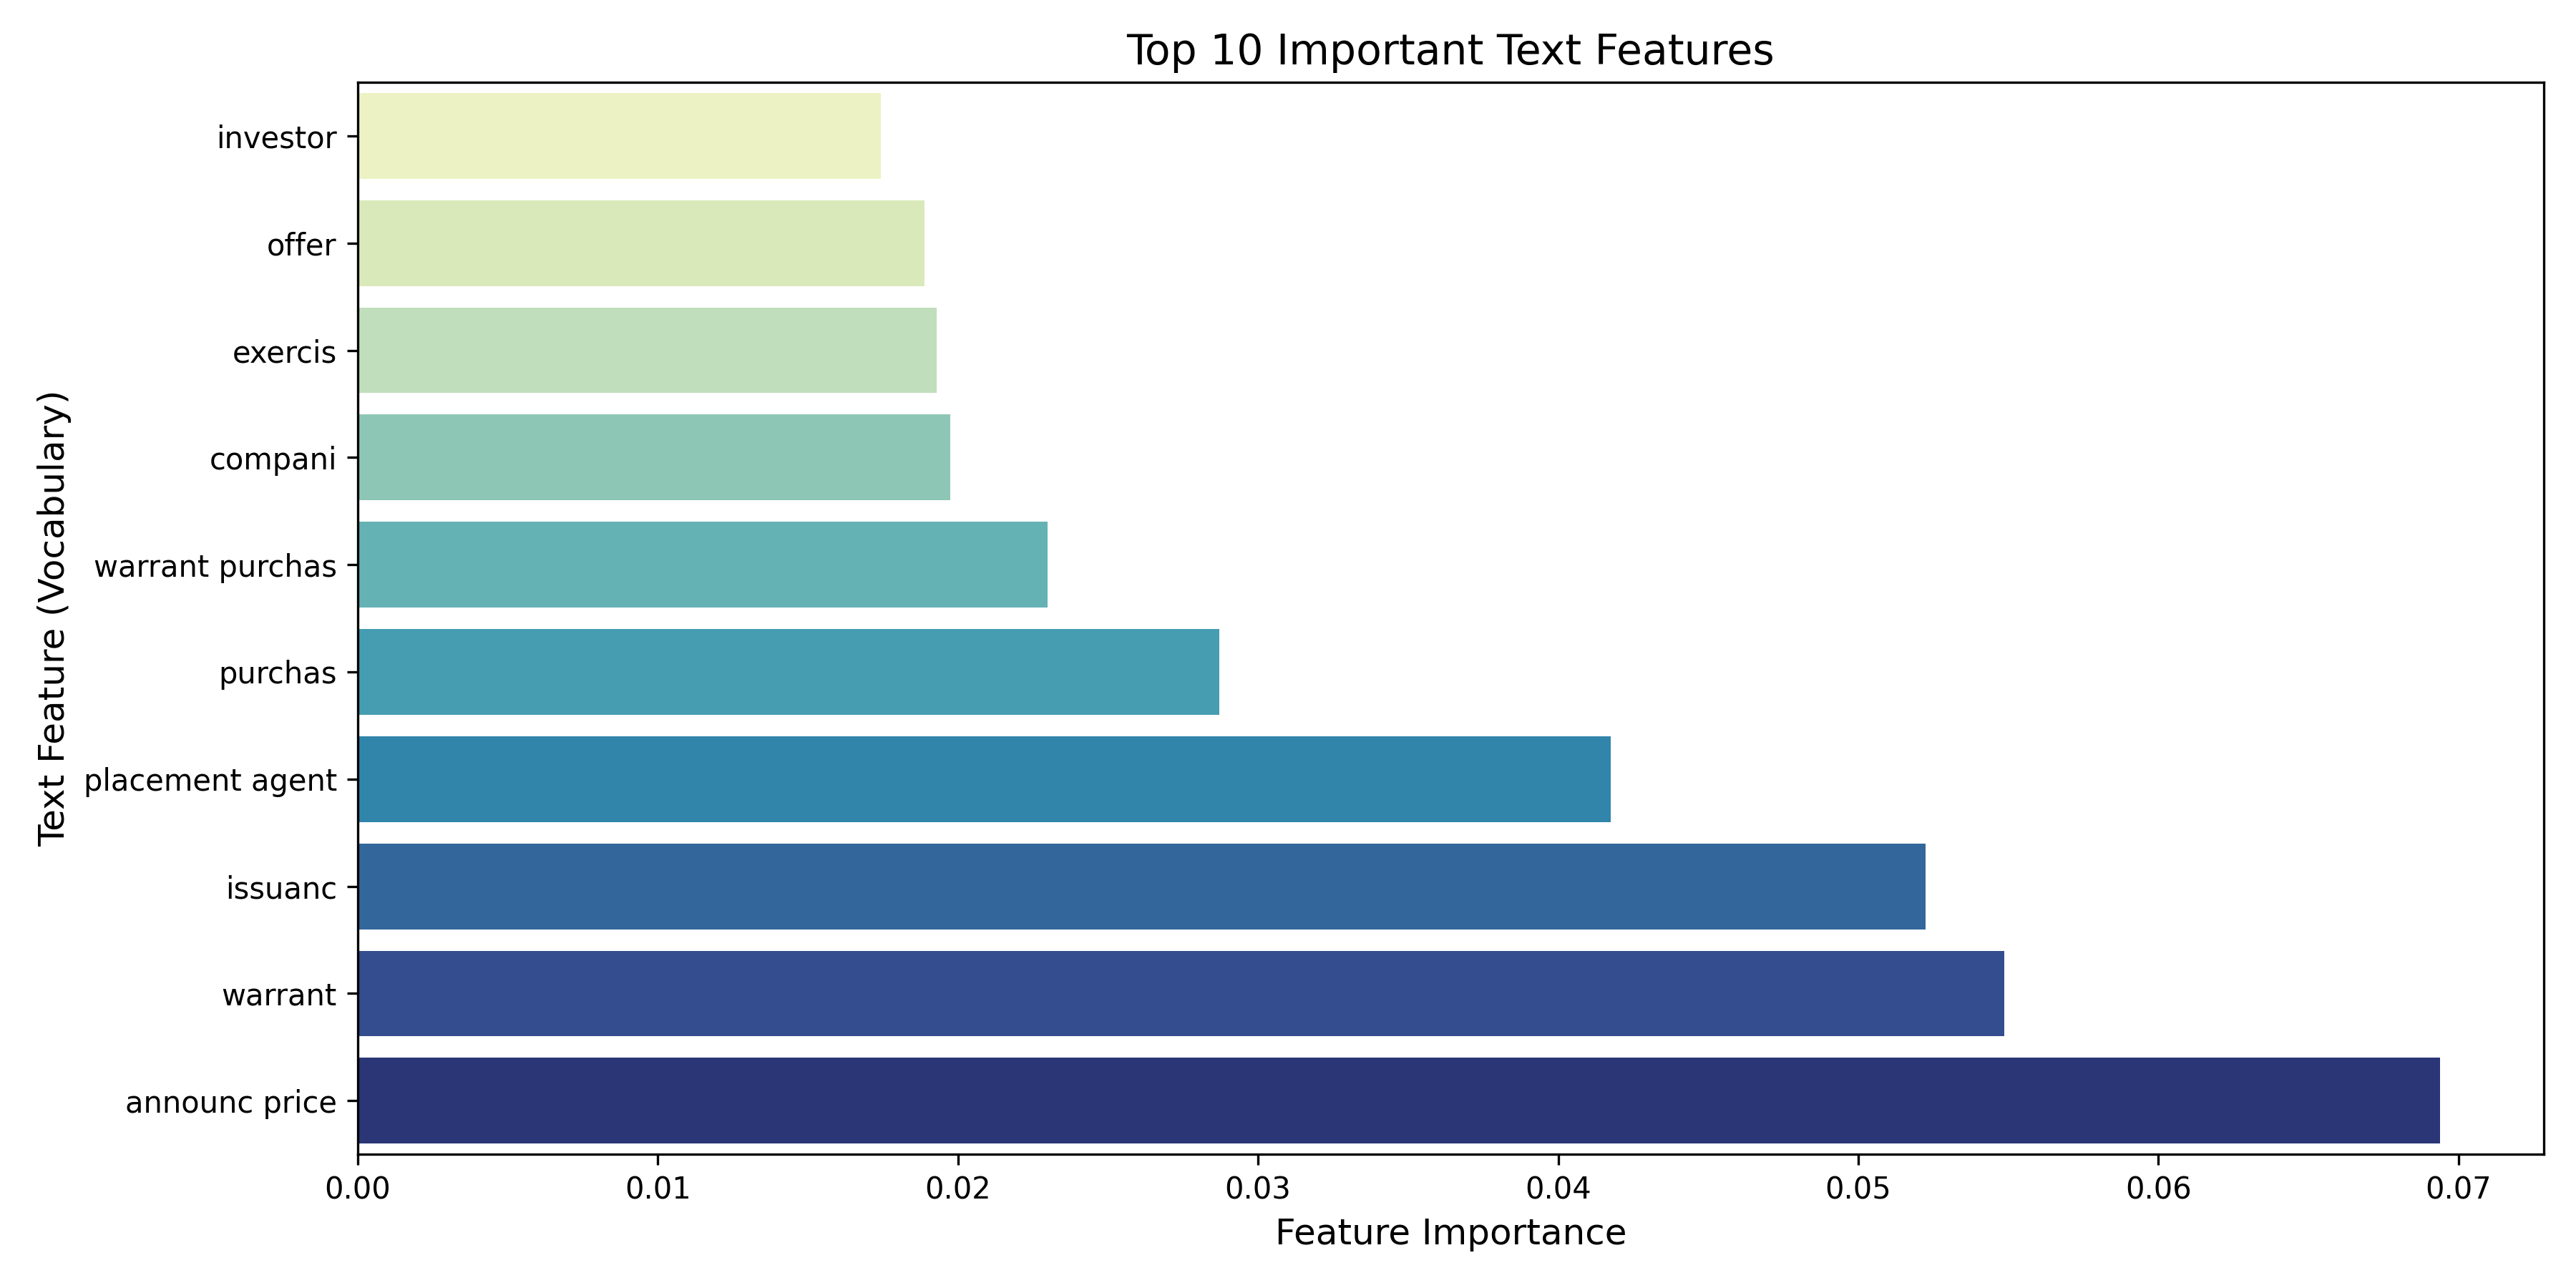


File: xgb_feature_importance.png


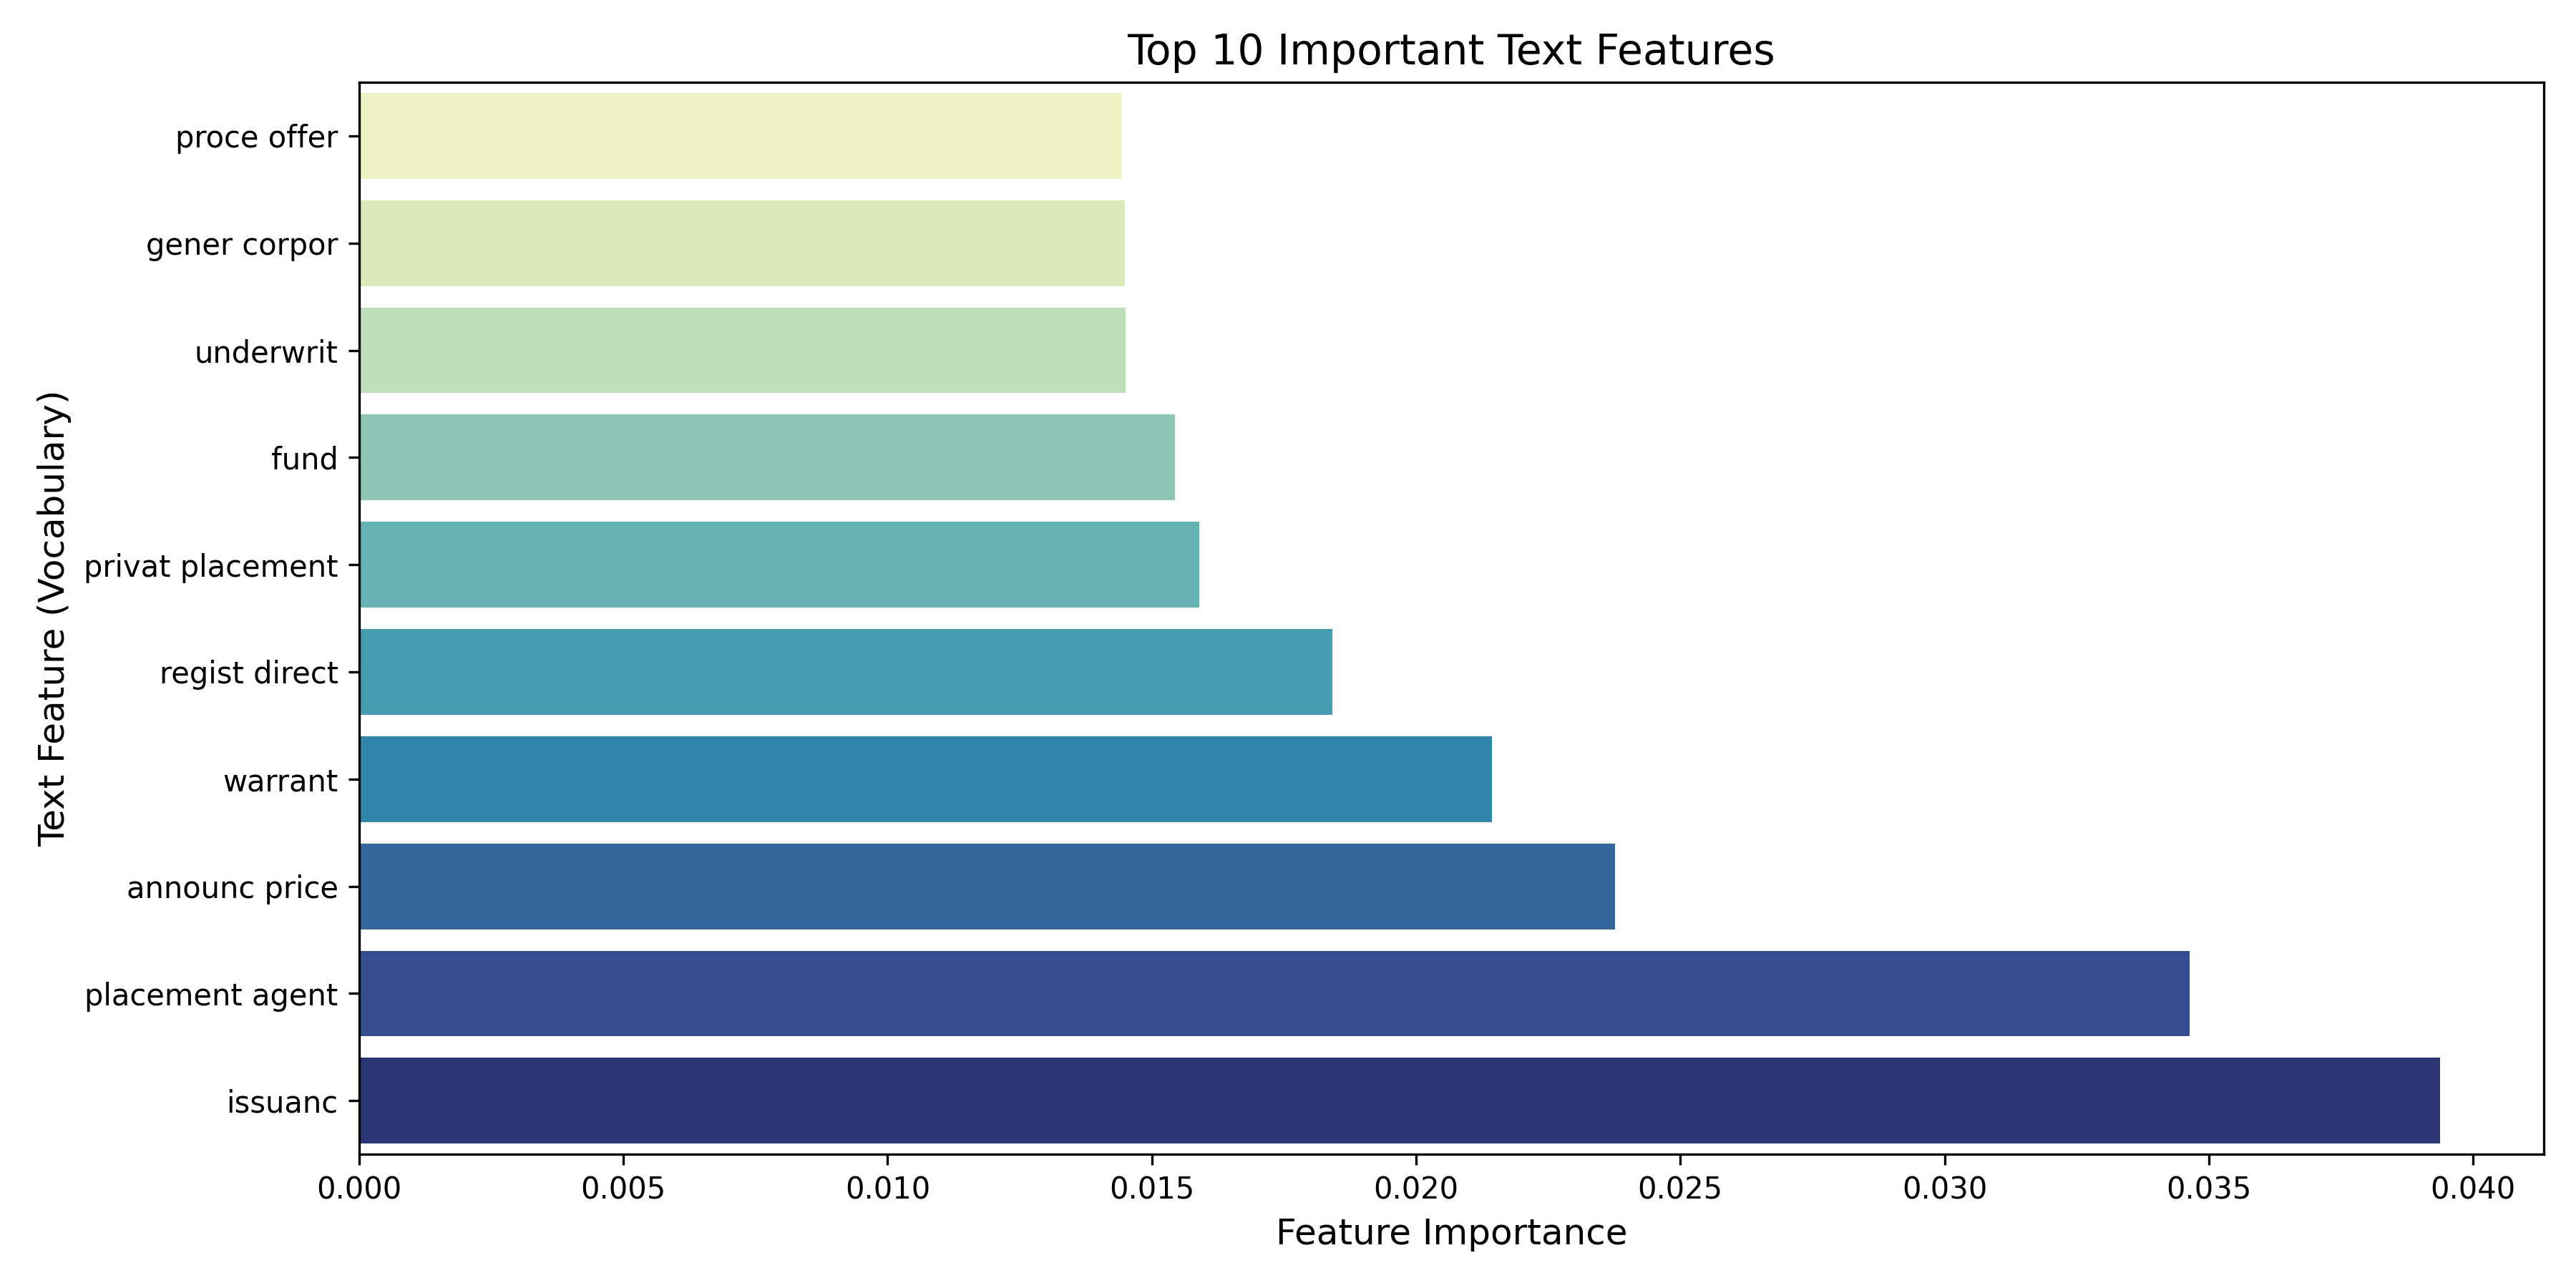

In [ ]:
import os
from IPython.display import display, Image

def display_folder_plots(result_dir):
    if not os.path.exists(result_dir):
        print(f"Directory not found: {result_dir}")
        return

    print(f"\n{'='*30}\nDISPLAYING ALL PLOTS IN: {result_dir}\n{'='*30}")
    files = sorted([f for f in os.listdir(result_dir) if f.endswith('.png')])

    for file in files:
        path = os.path.join(result_dir, file)
        print(f"\nFile: {file}")
        display(Image(filename=path, width=700))

# Cell 1: TF-IDF Results
display_folder_plots('/content/tfidf_result')

In [ ]:
import os
from IPython.display import display, Image

def display_impact_plots(result_dirs):
    impact_keywords = ['impact', 'heatmap']
    for result_dir in result_dirs:
        print(f"\n--- Parameter Impact Plots in {result_dir} ---")
        files = sorted([f for f in os.listdir(result_dir) if any(k in f for k in impact_keywords)])
        for file in files:
            print(f"File: {file}")
            display(Image(filename=os.path.join(result_dir, file), width=600))

display_impact_plots(['/content/tfidf_result', '/content/bow_result'])


--- Parameter Impact Plots in /content/tfidf_result ---

--- Parameter Impact Plots in /content/bow_result ---



--- Searching for Impact Plots related to: tfidf_result ---
Displaying from root: tfidf_resultrf_reg_param_heatmap_text.png


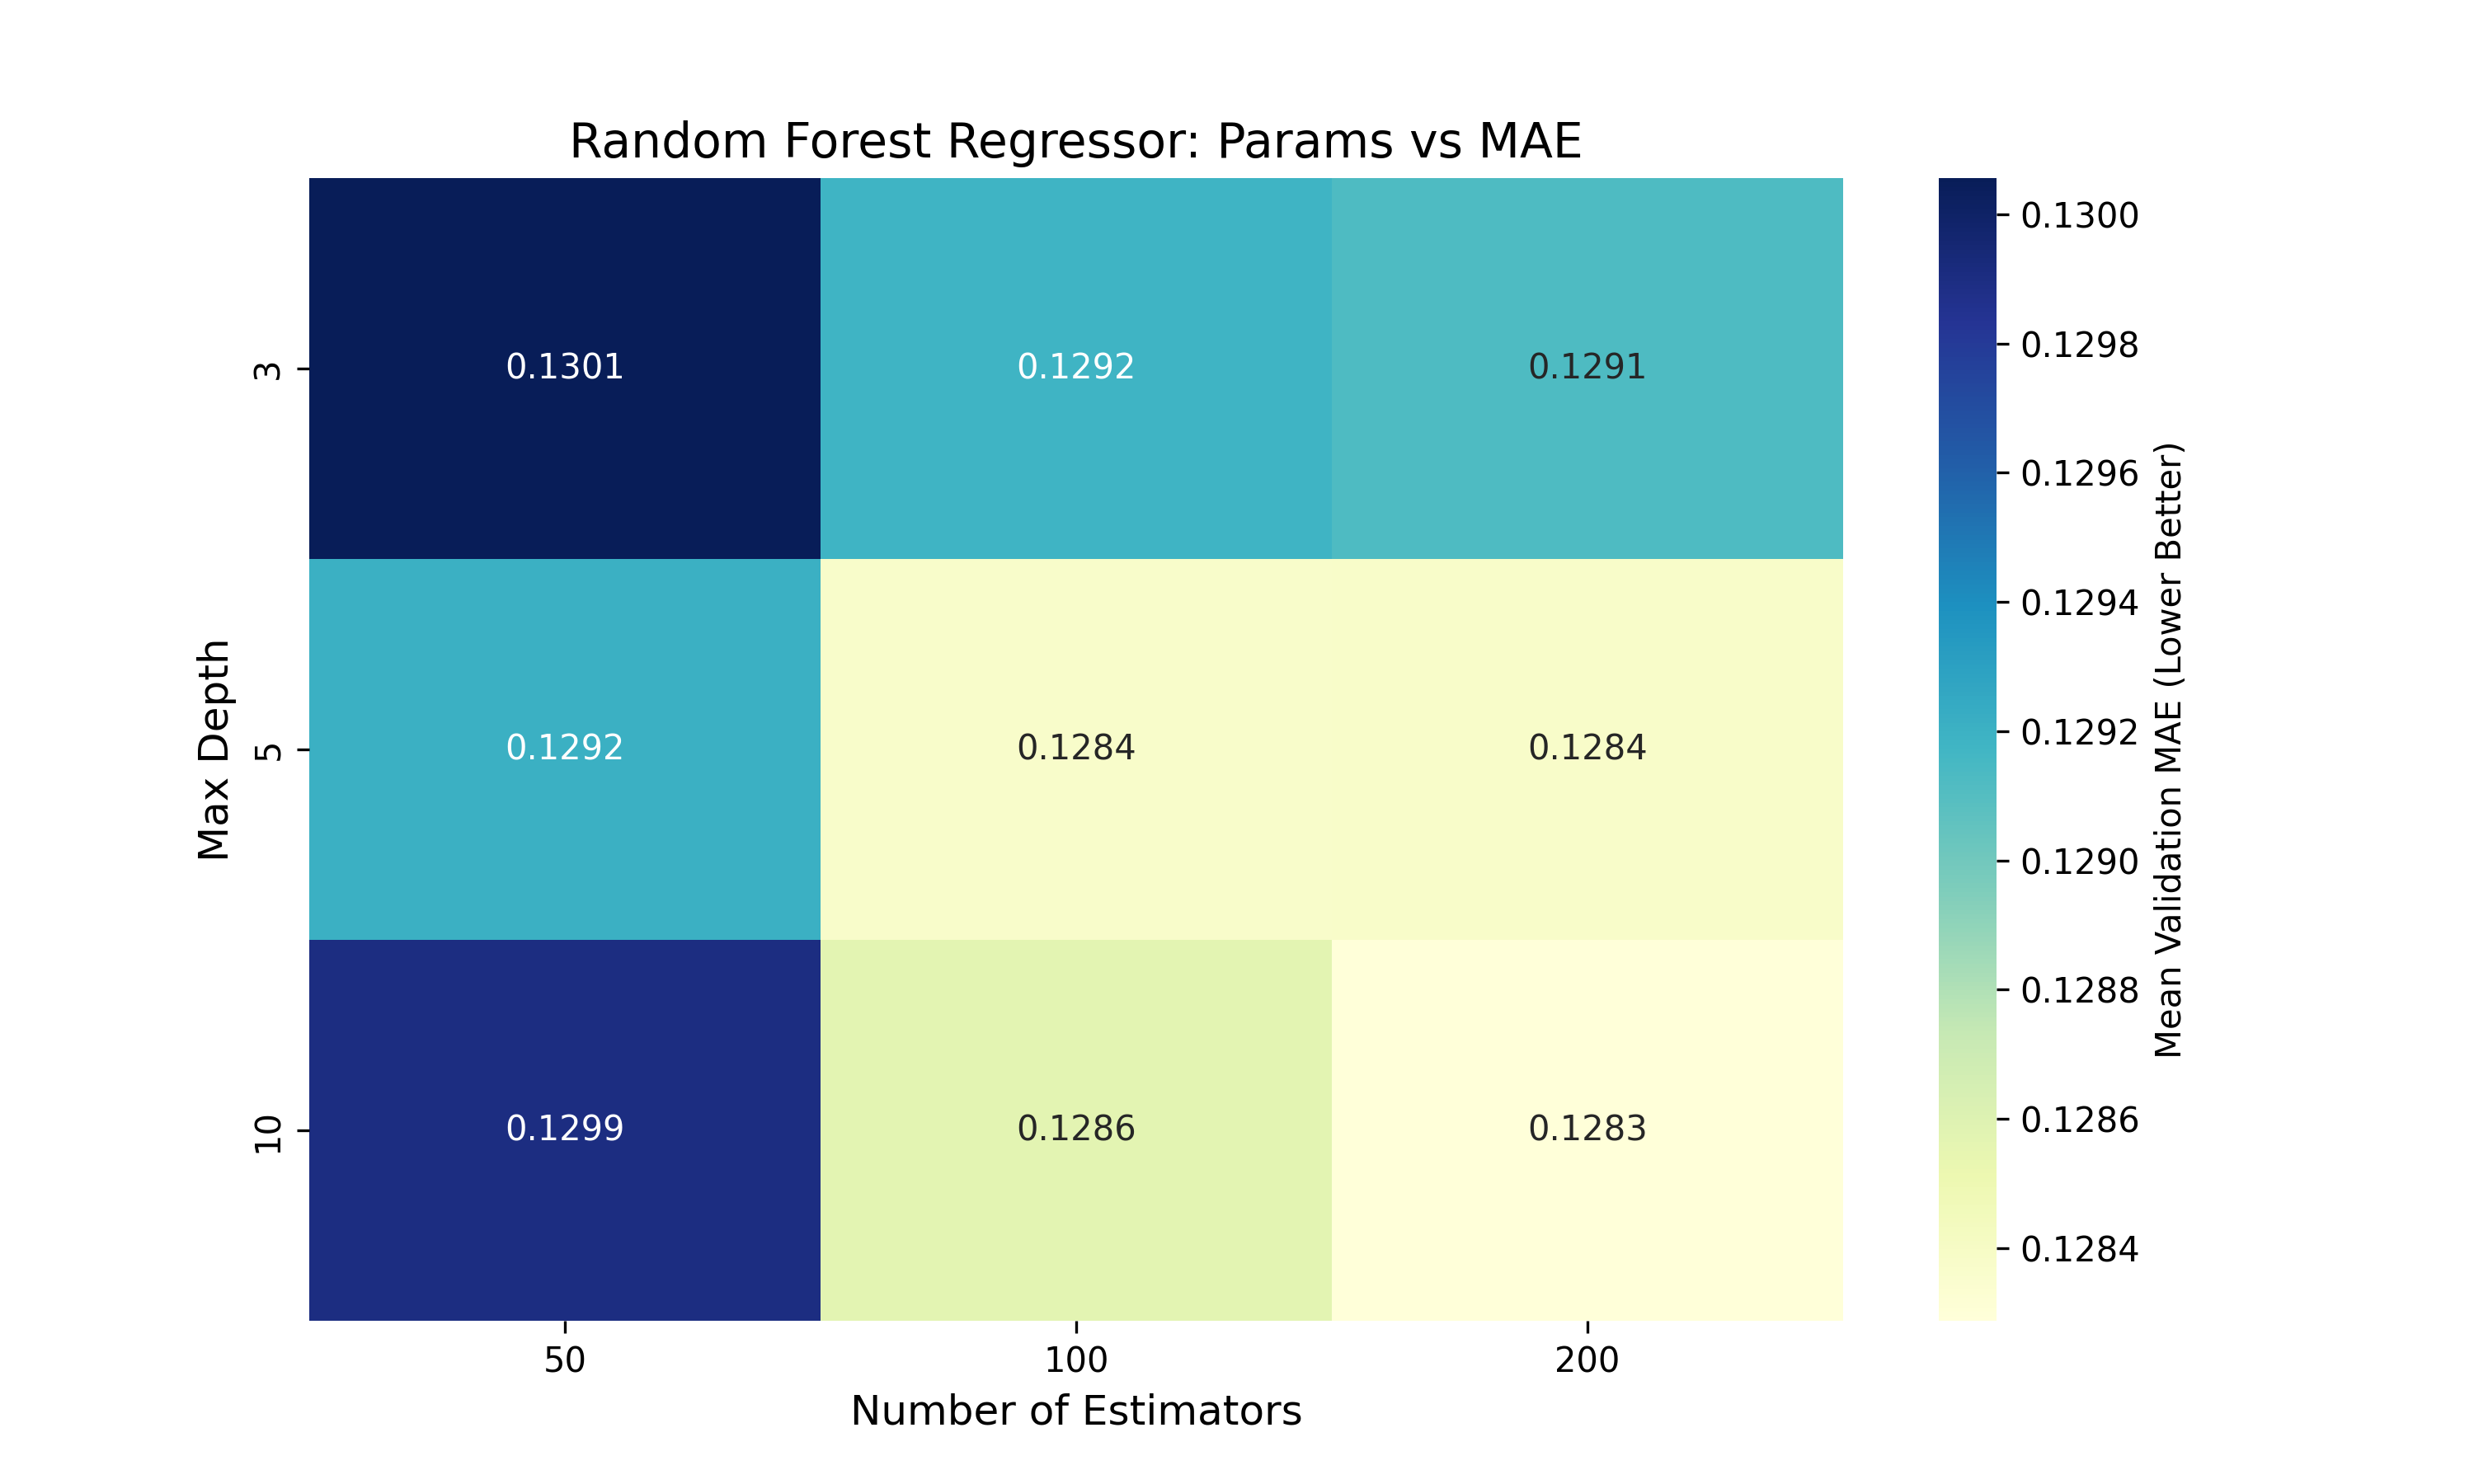

Displaying from root: tfidf_resultridge_alpha_impact_text.png


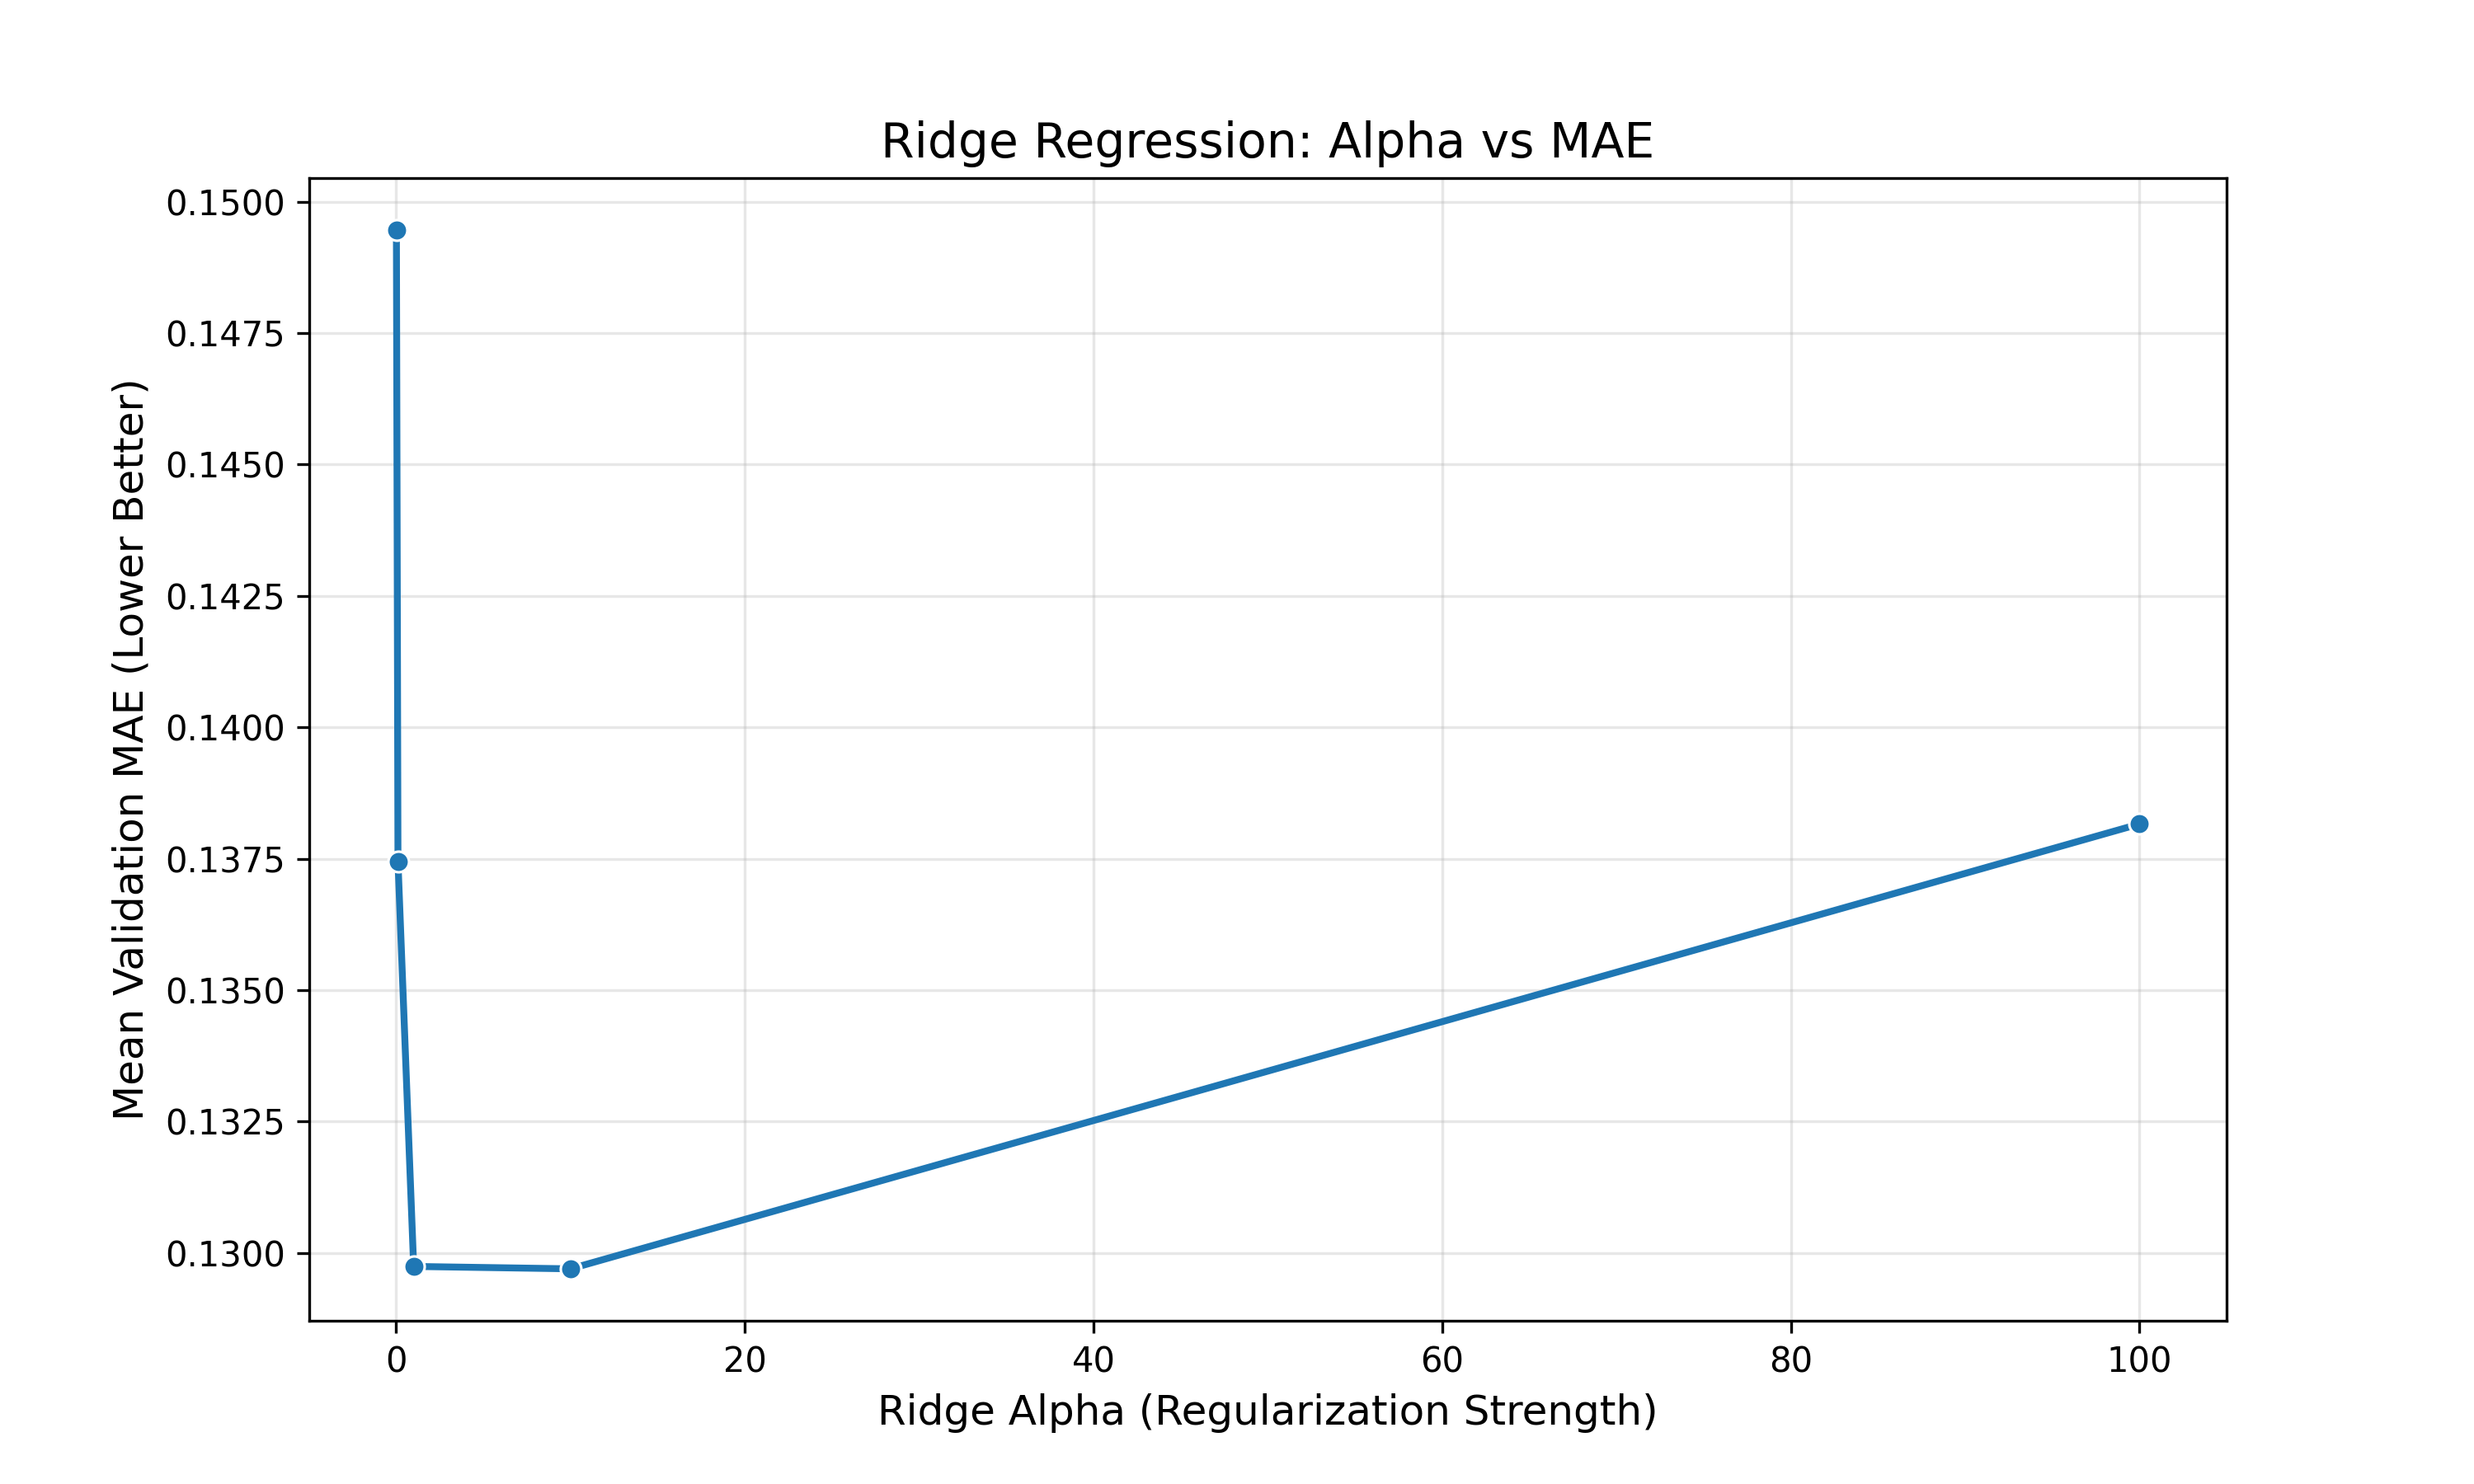

Displaying from root: tfidf_resultxgb_lr_depth_impact_text.png


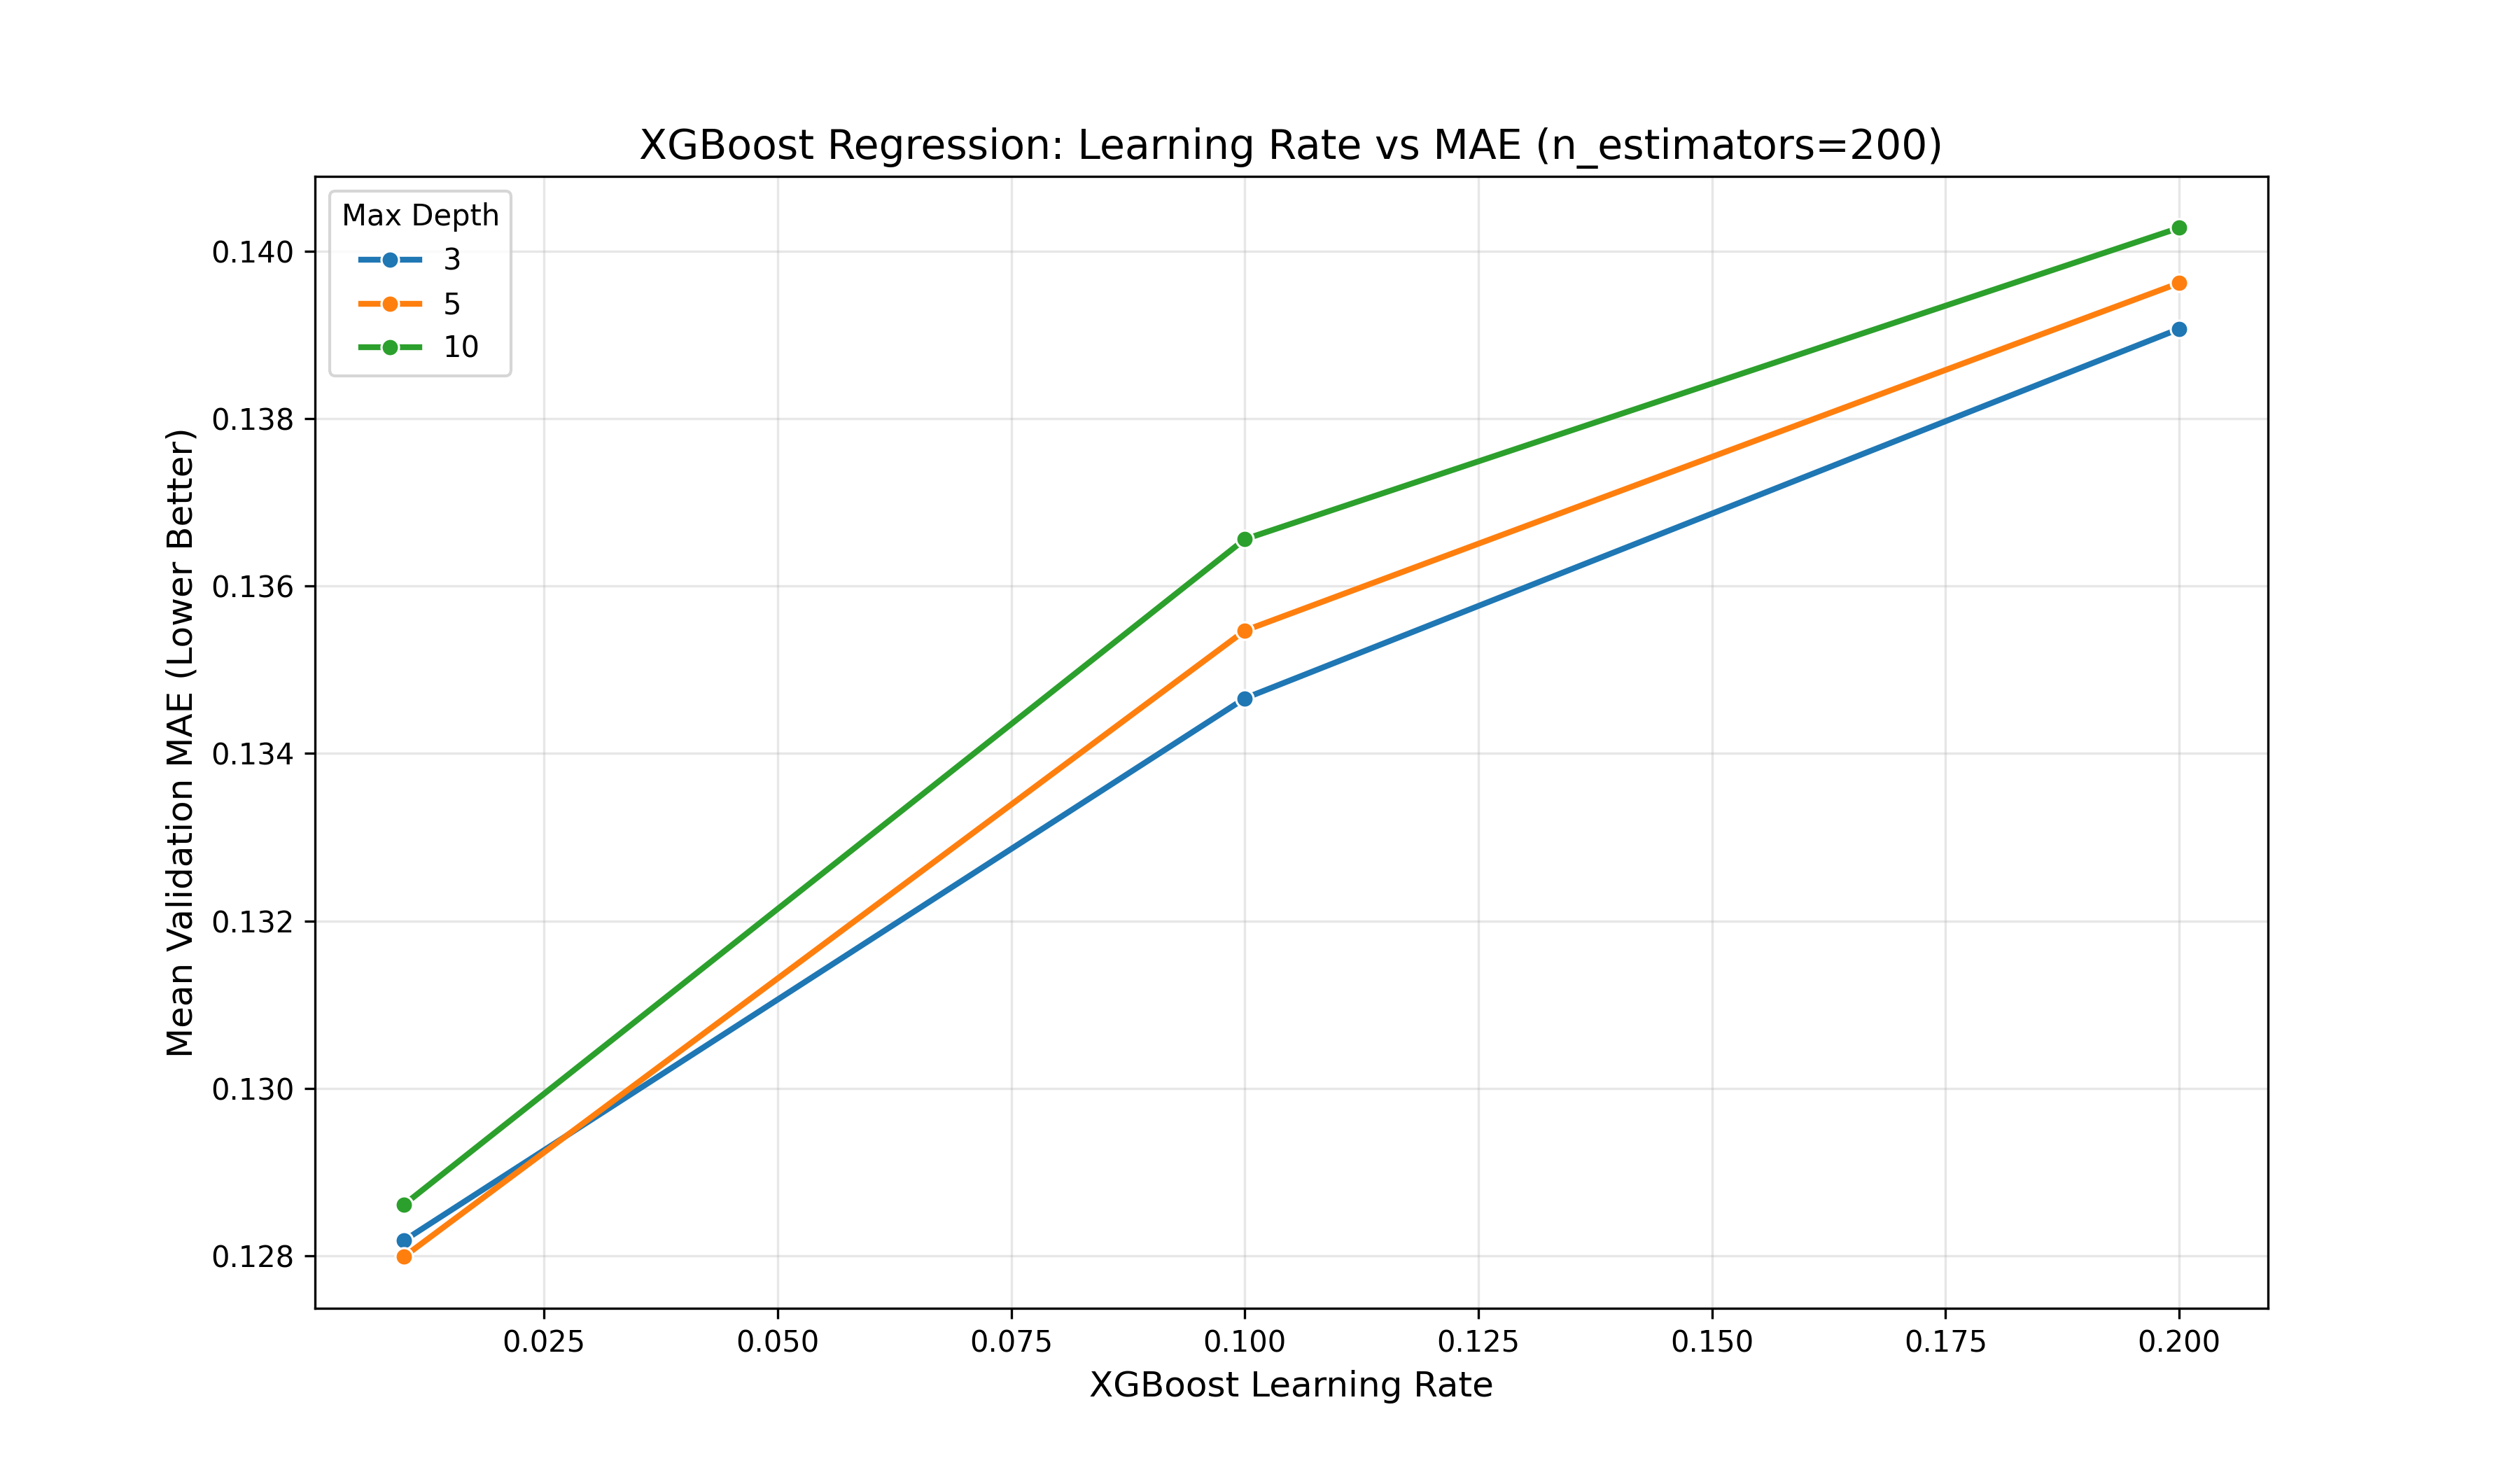

Displaying from root: tfidf_resultxgb_n_est_impact_text.png


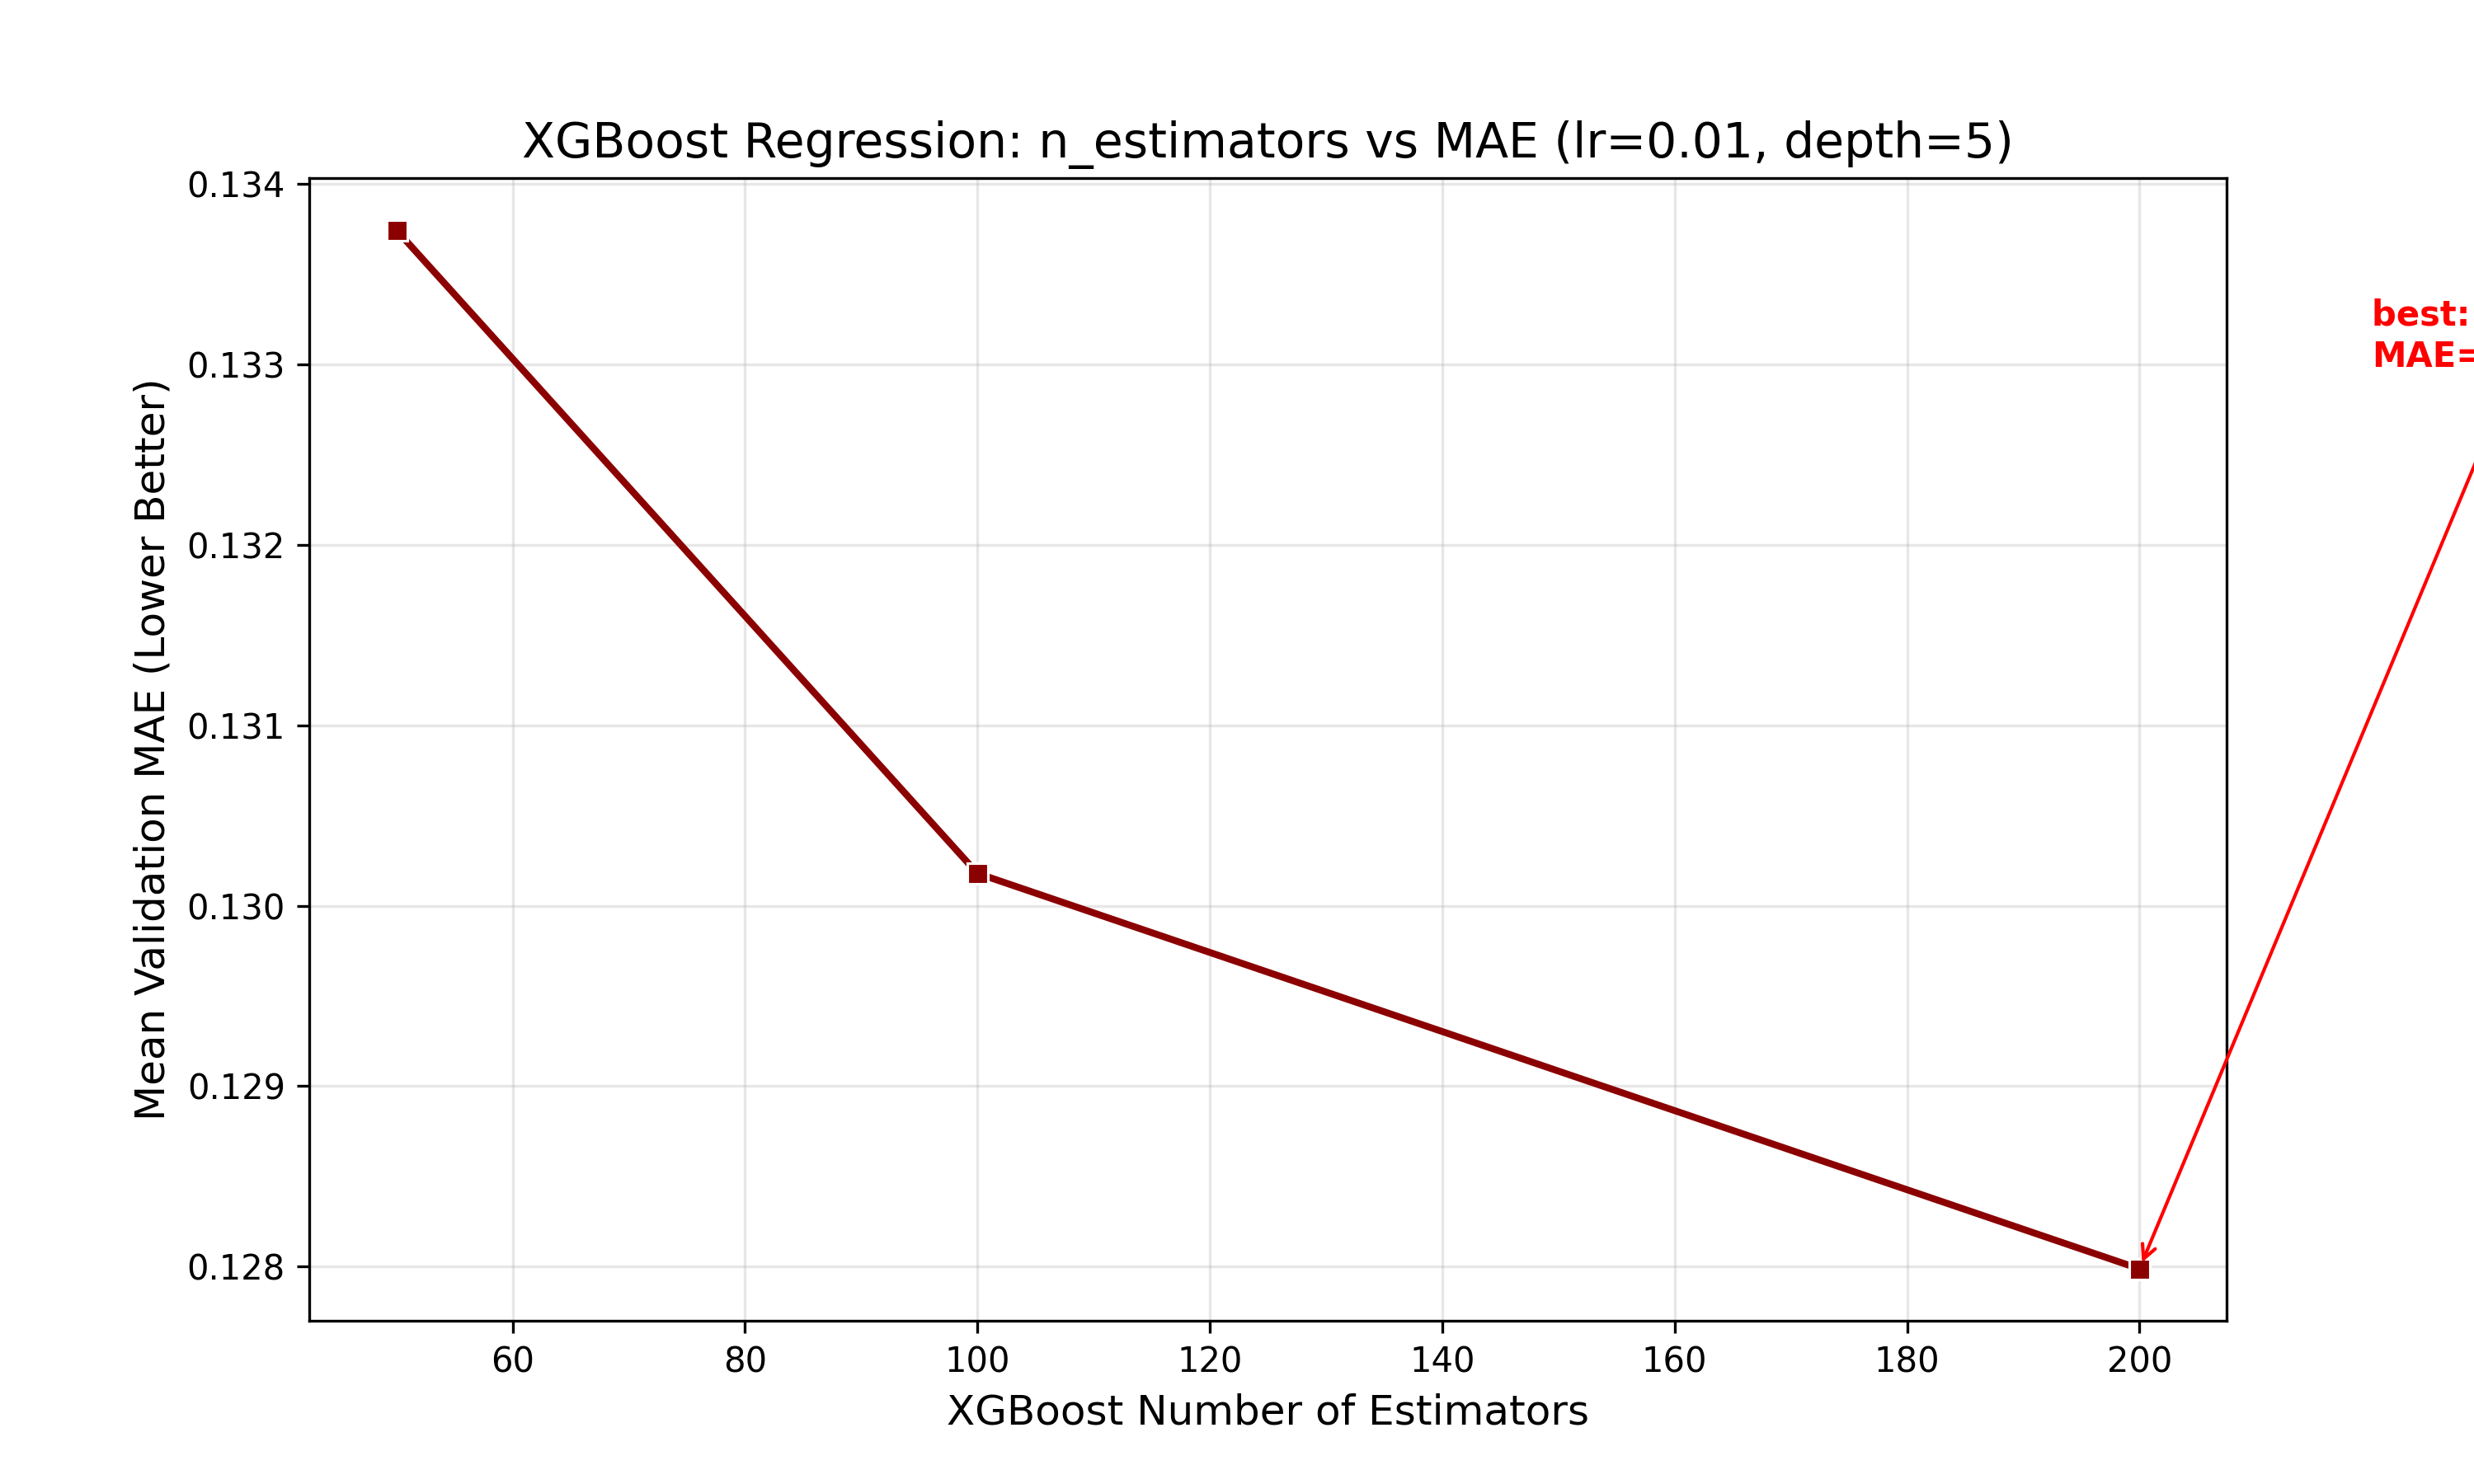


--- Searching for Impact Plots related to: bow_result ---
Displaying from root: bow_resultrf_reg_param_heatmap_text.png


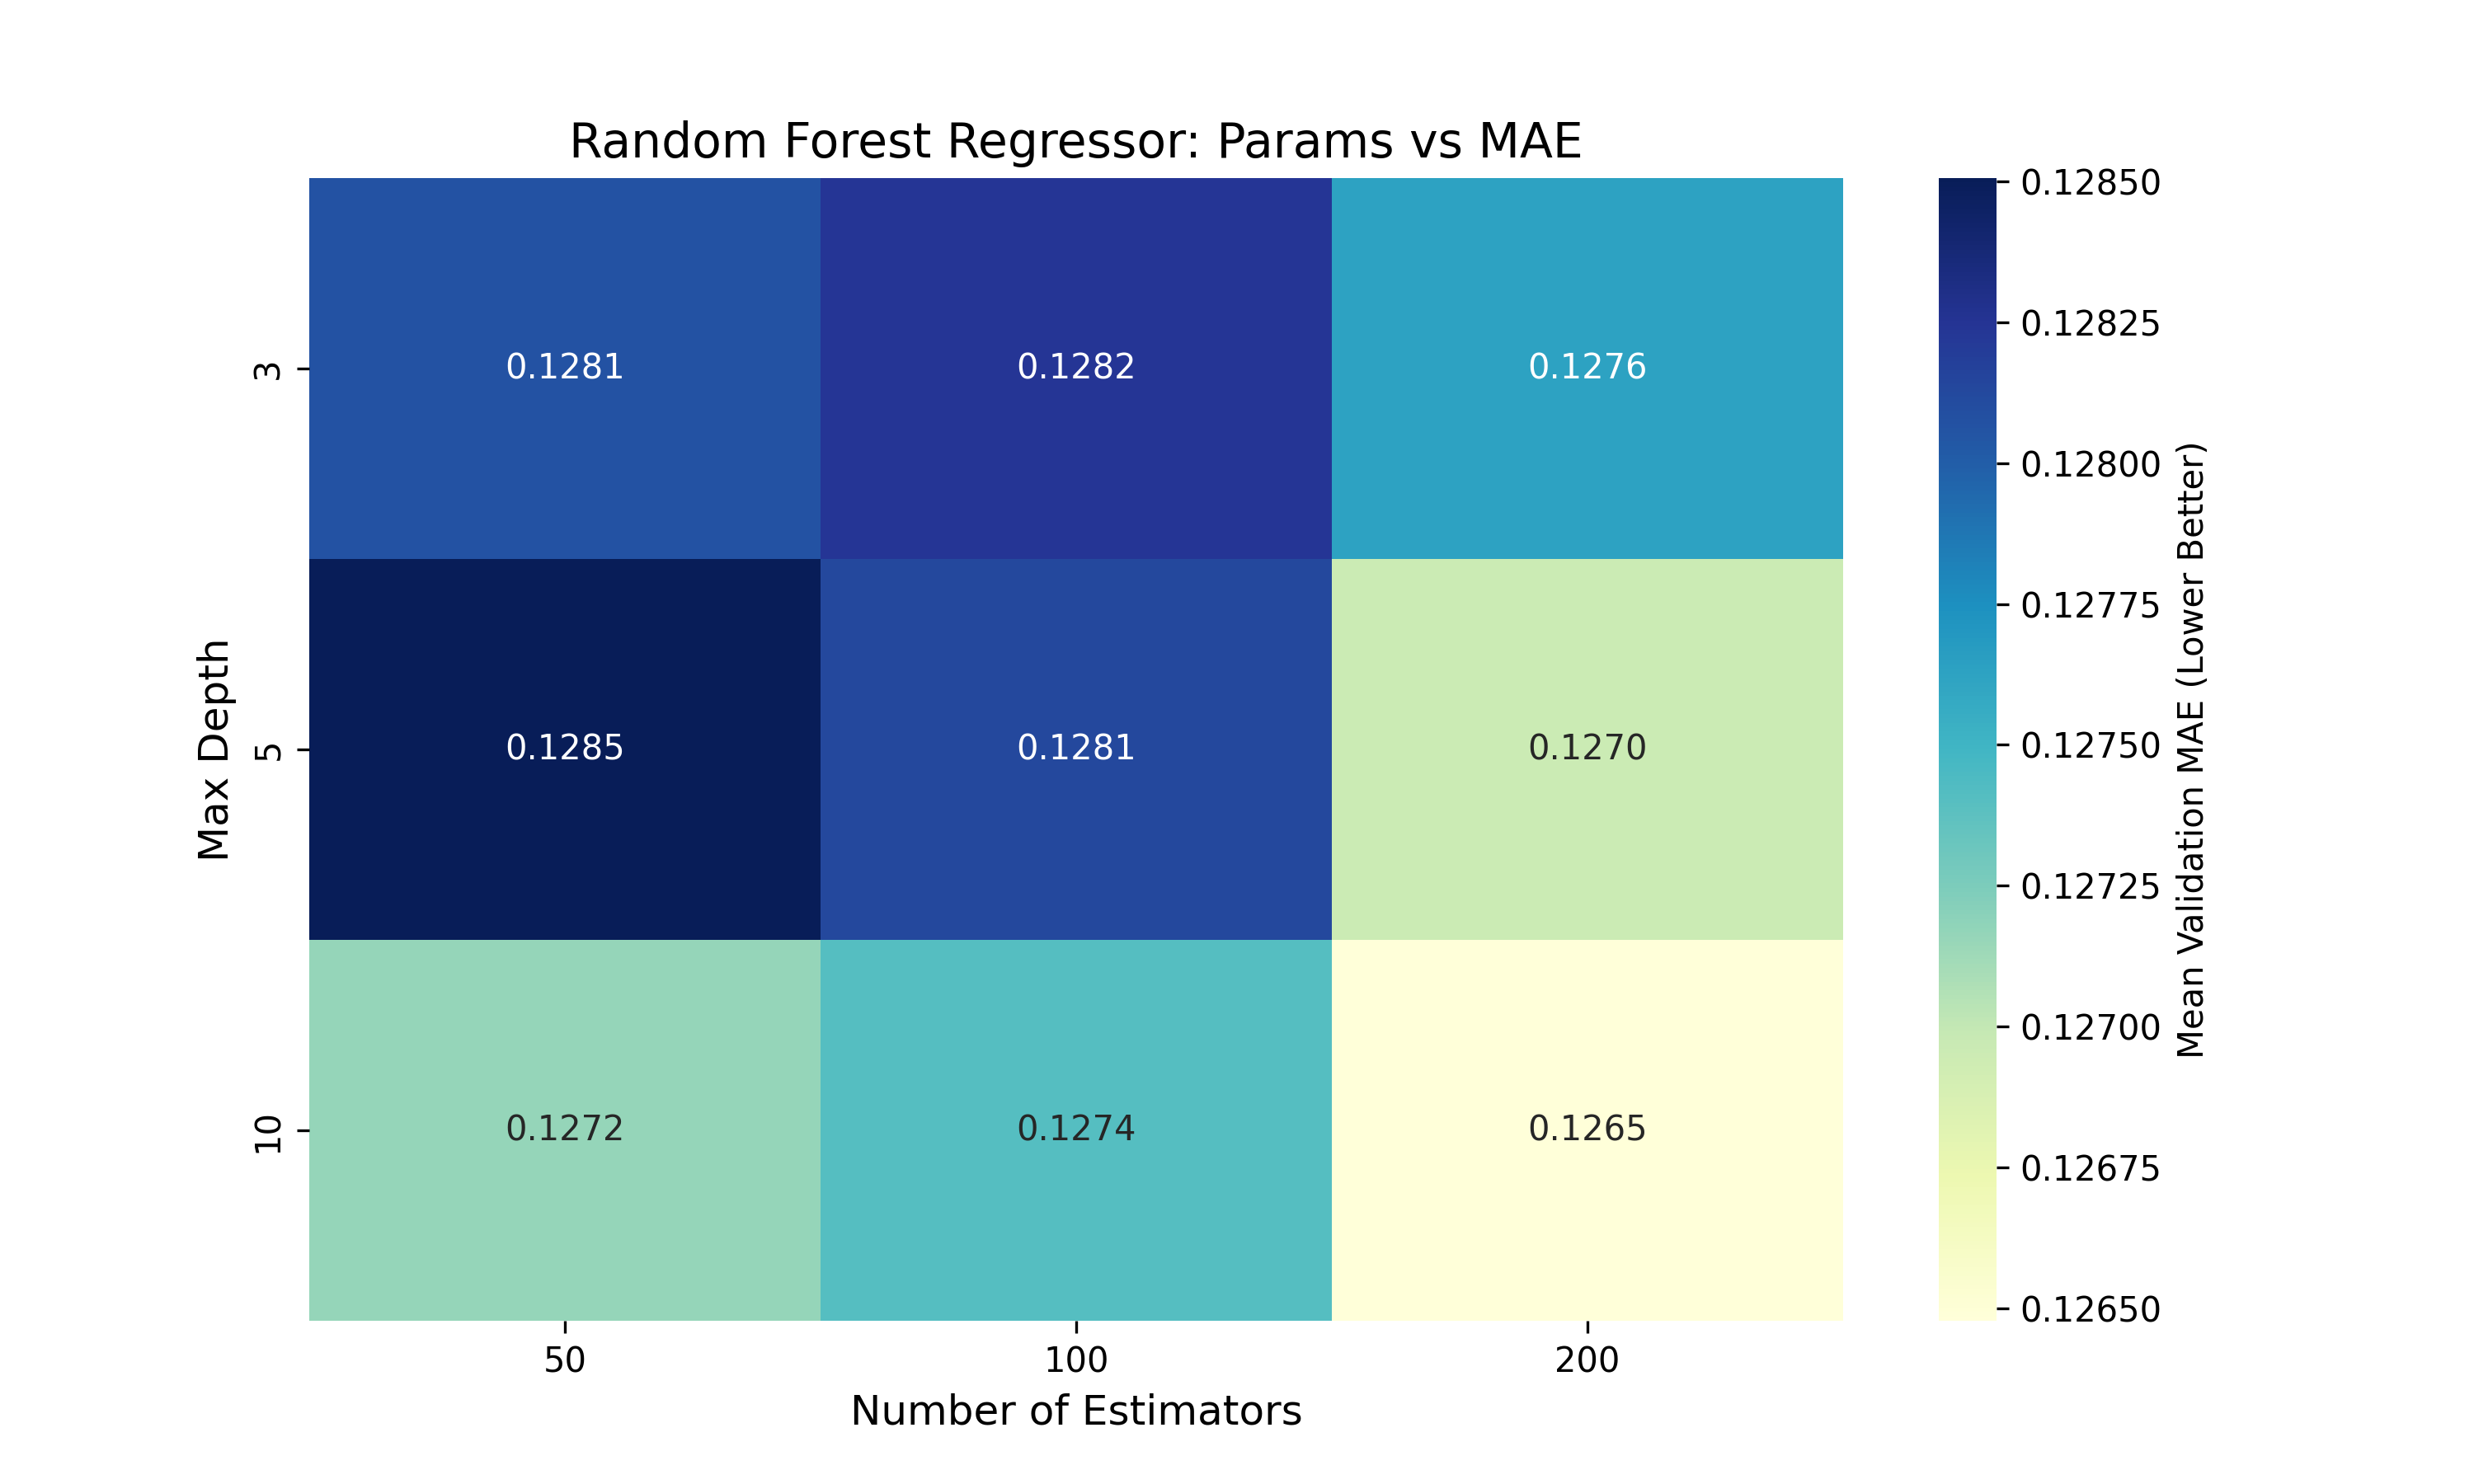

Displaying from root: bow_resultridge_alpha_impact_text.png


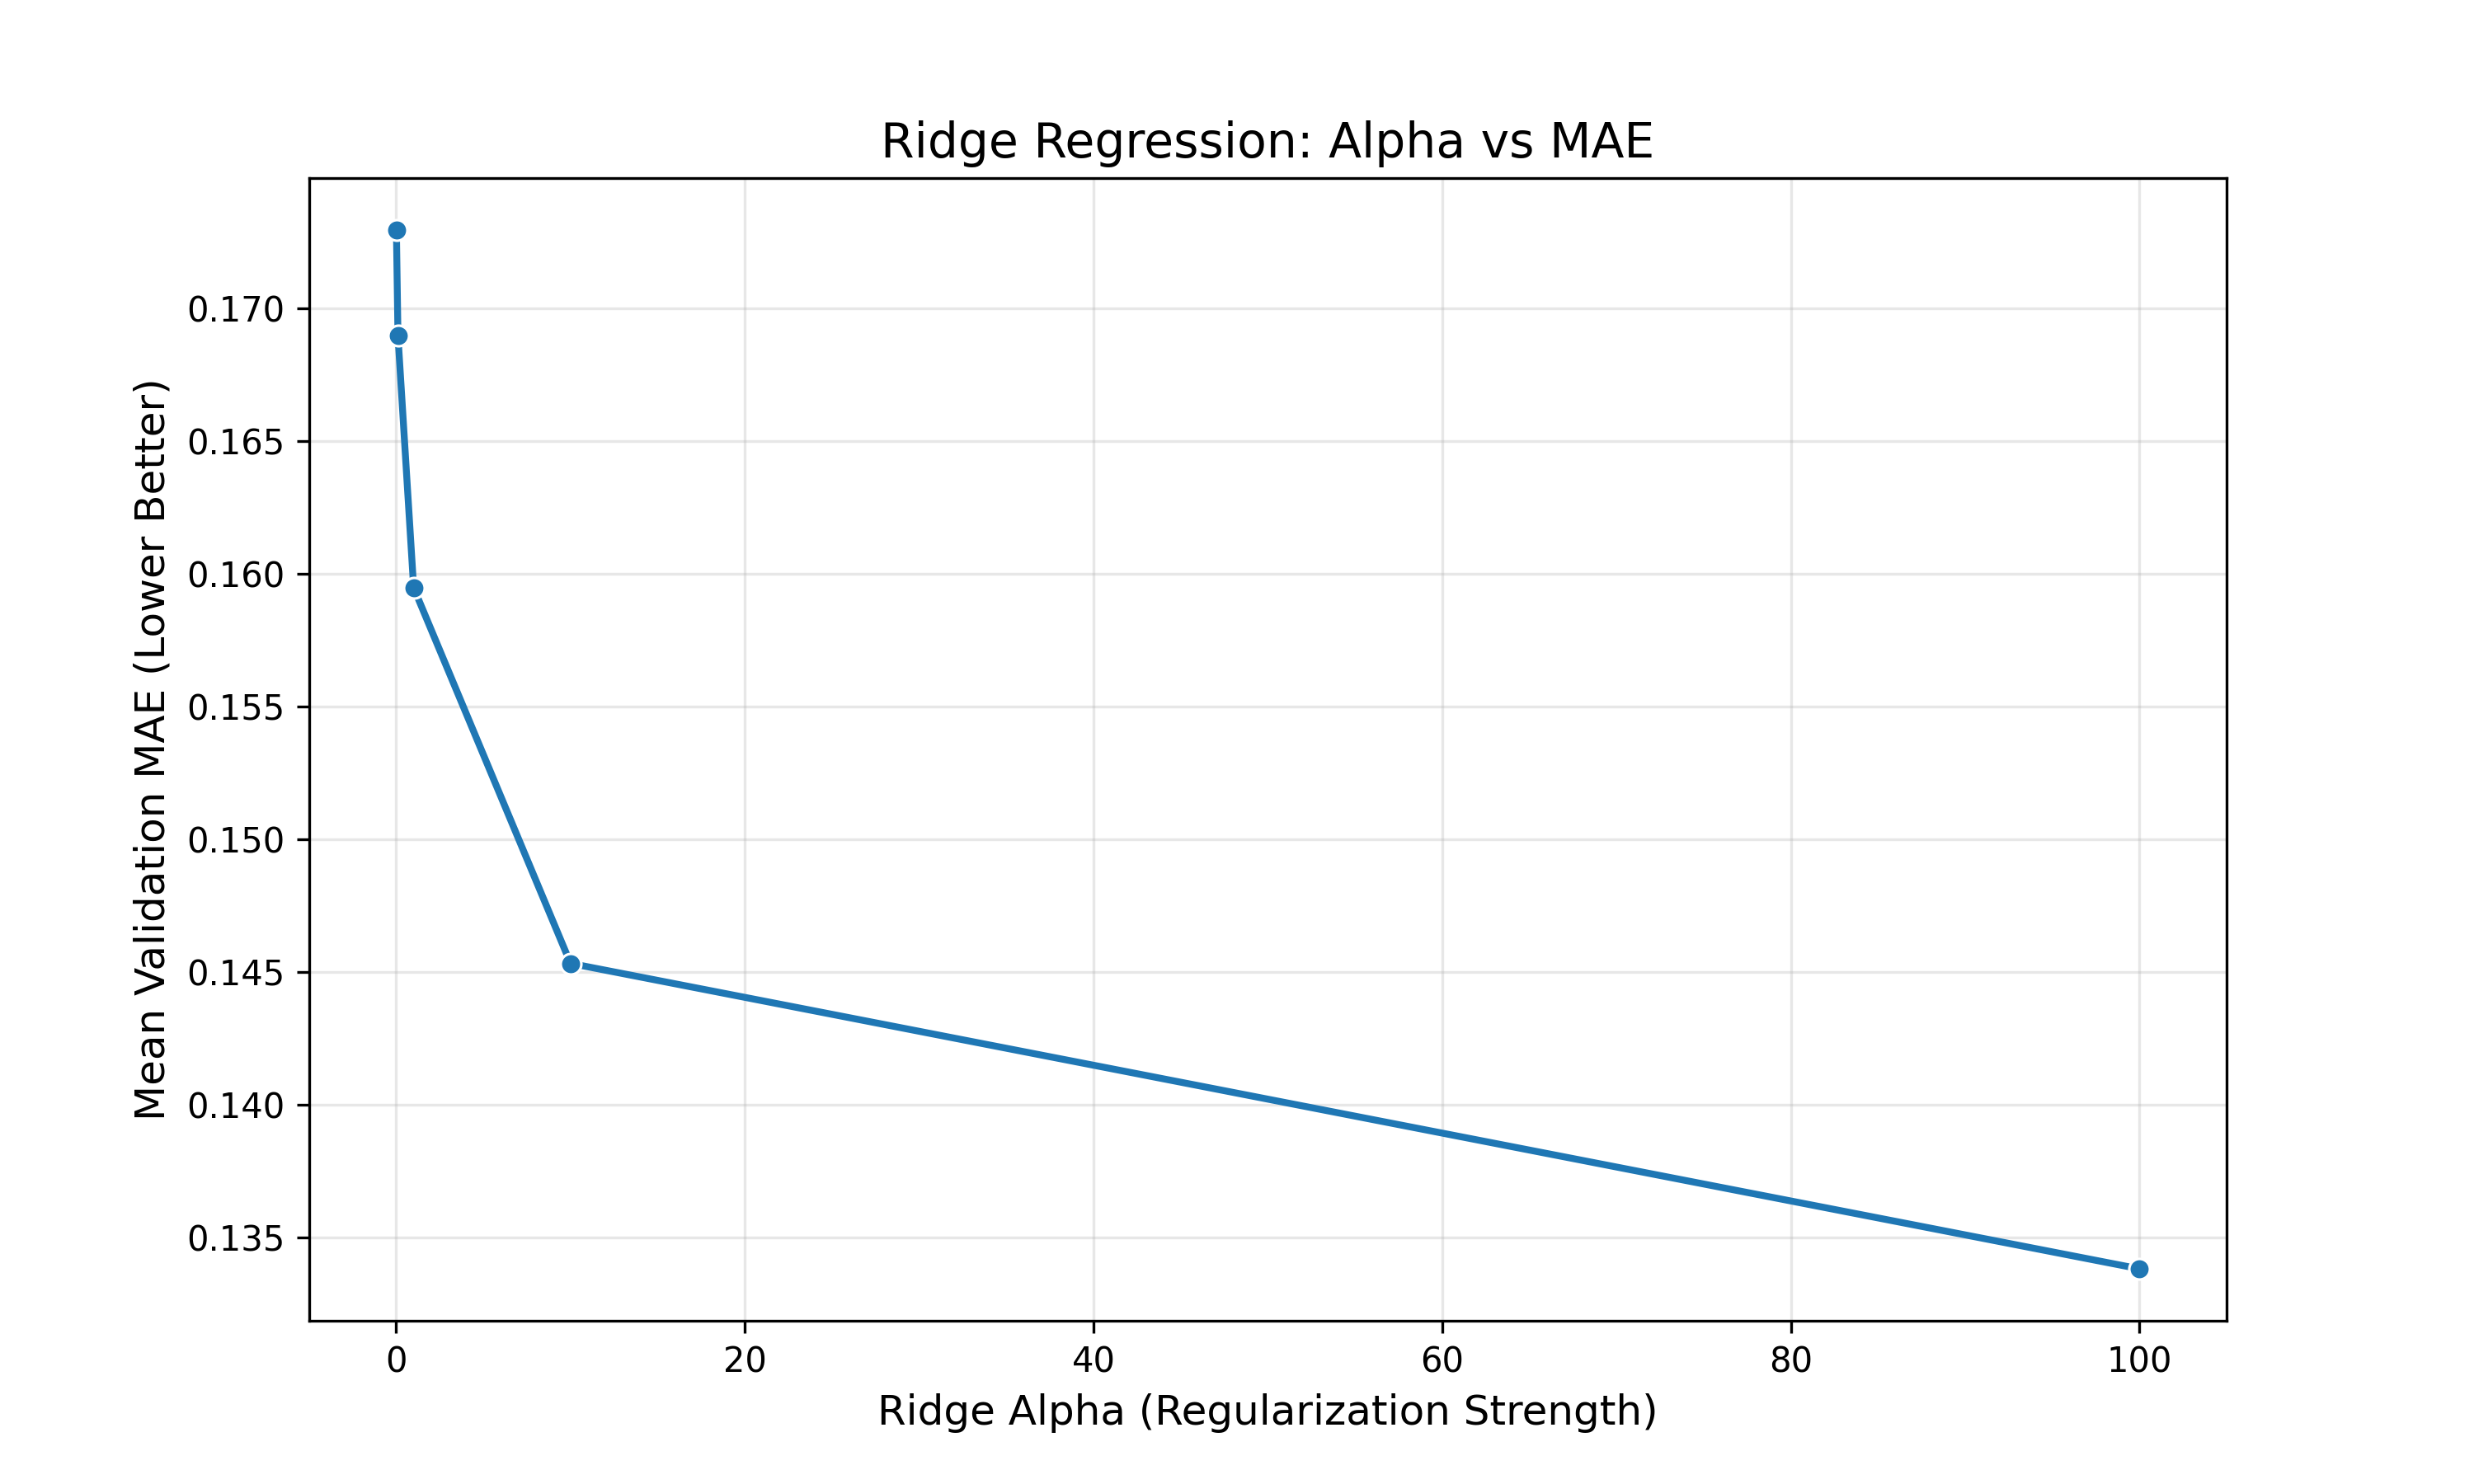

Displaying from root: bow_resultxgb_lr_depth_impact_text.png


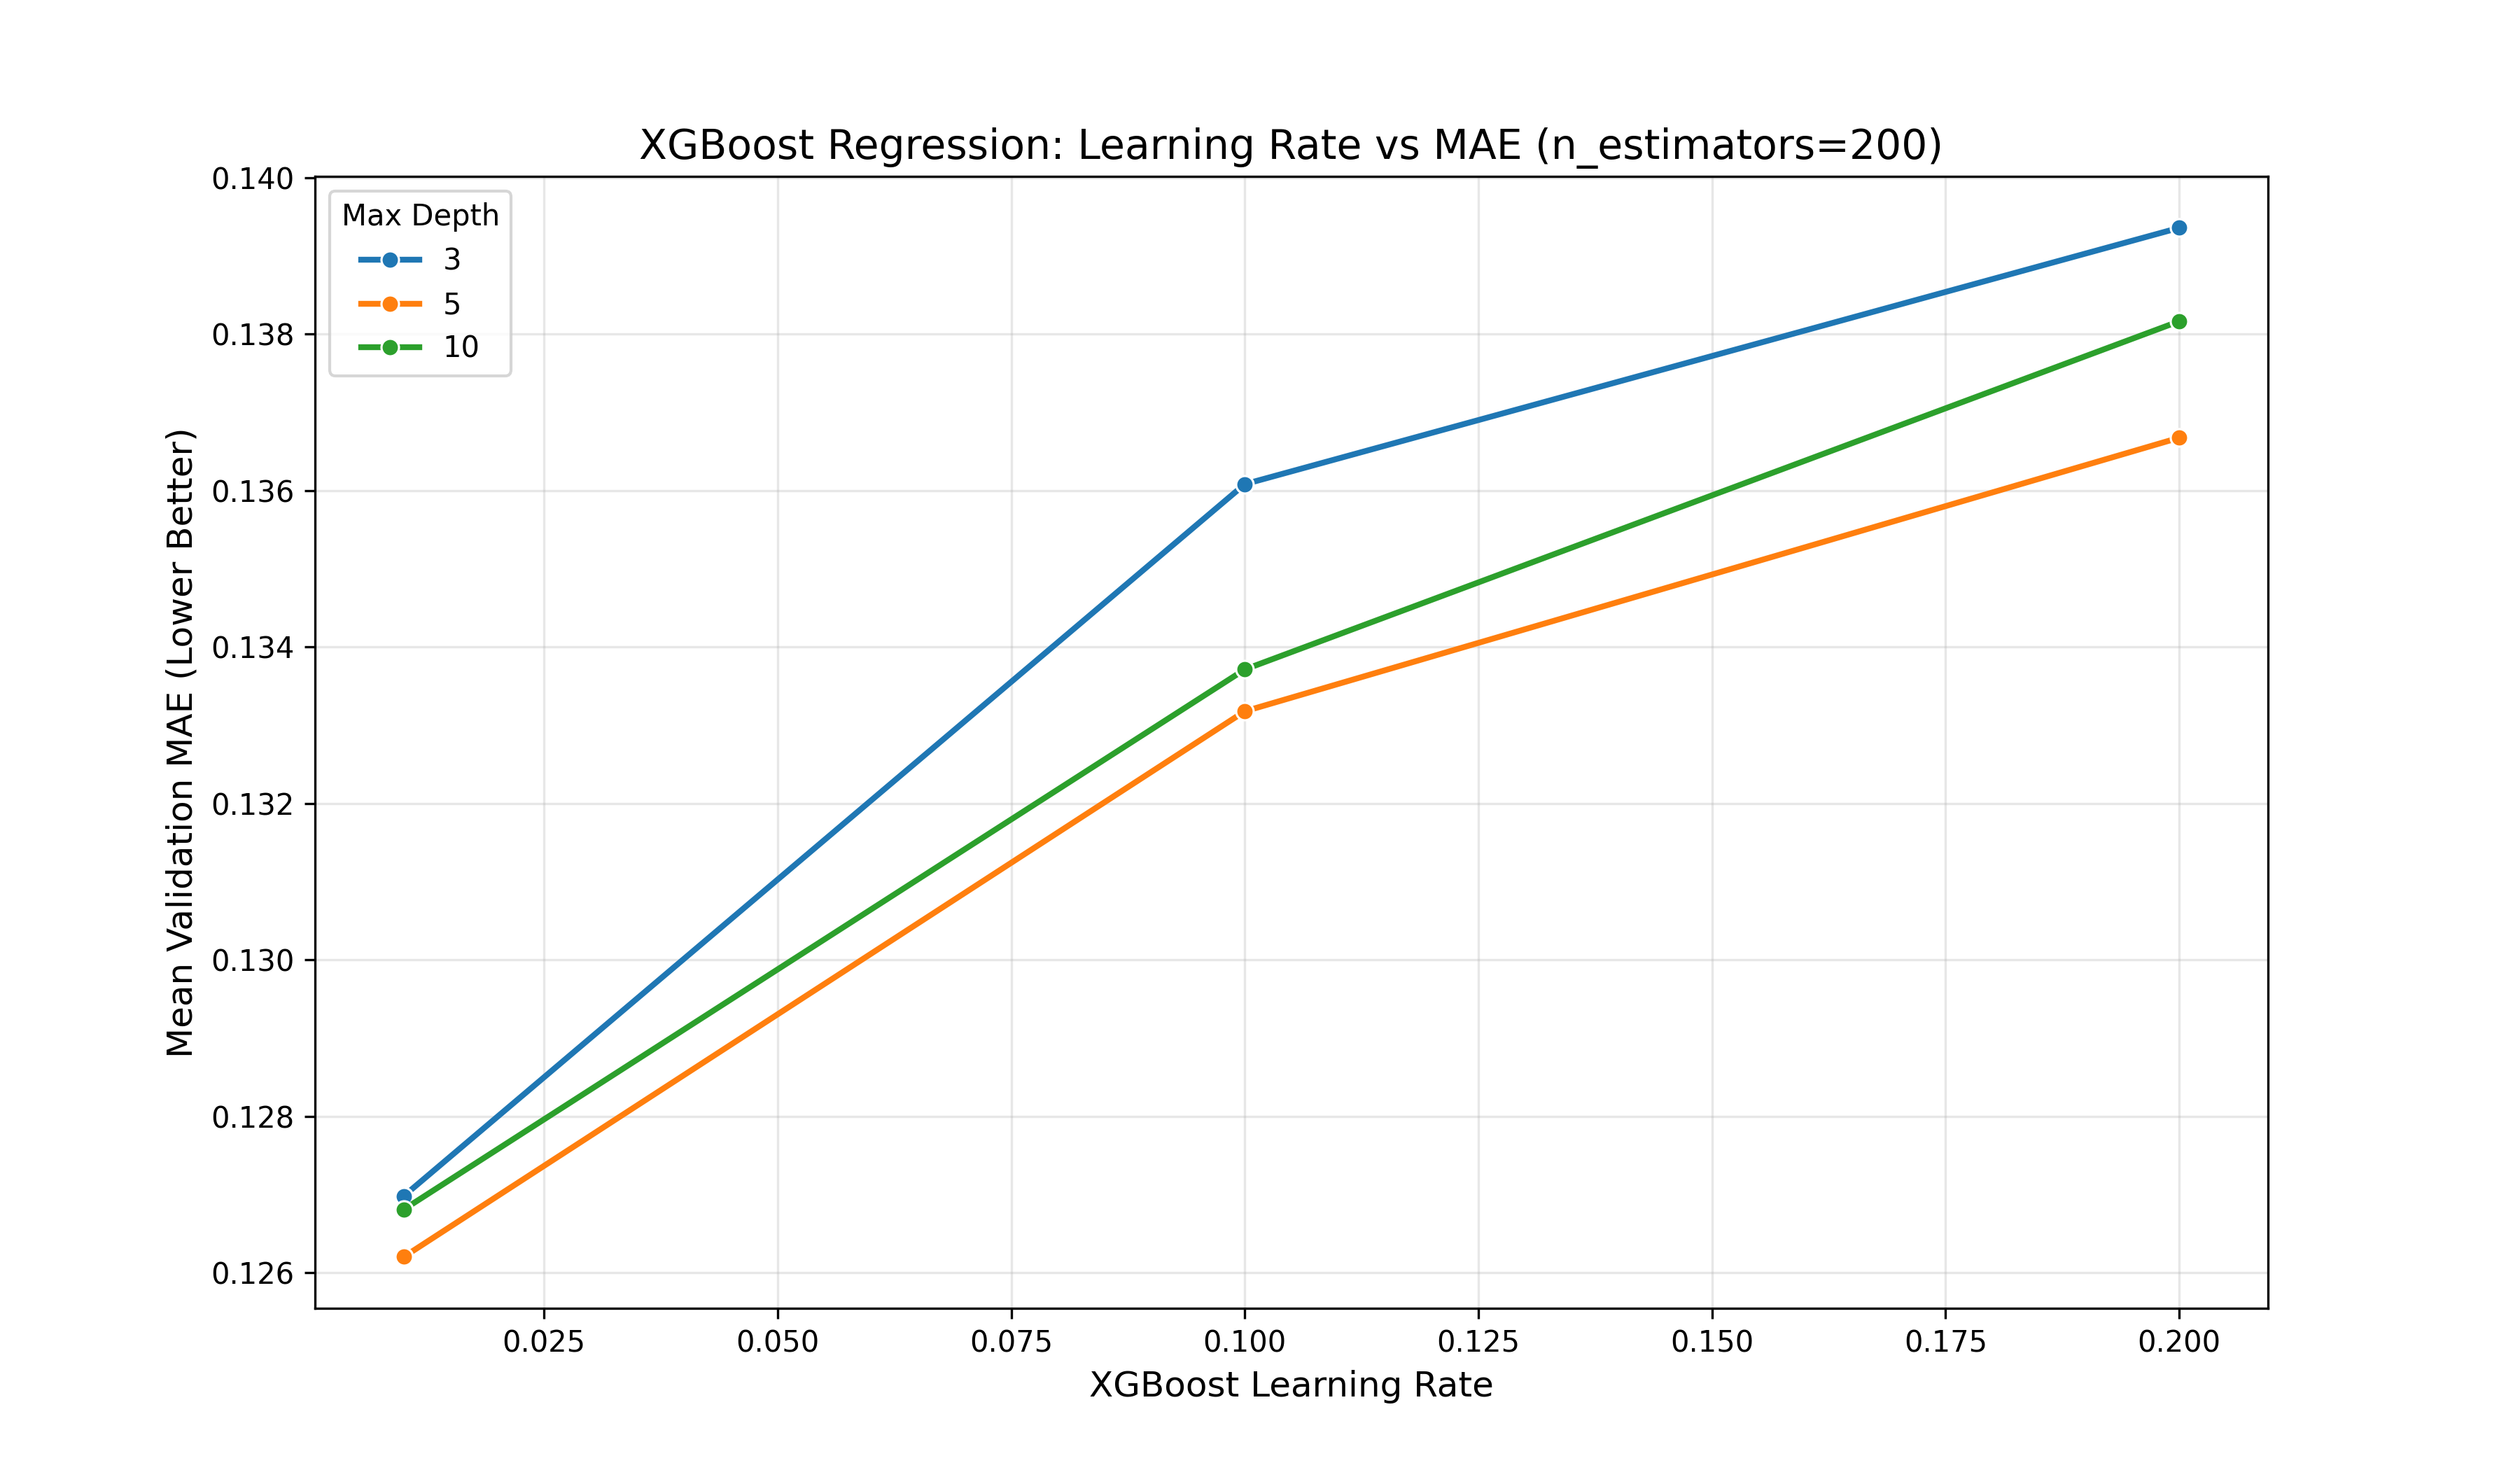

Displaying from root: bow_resultxgb_n_est_impact_text.png


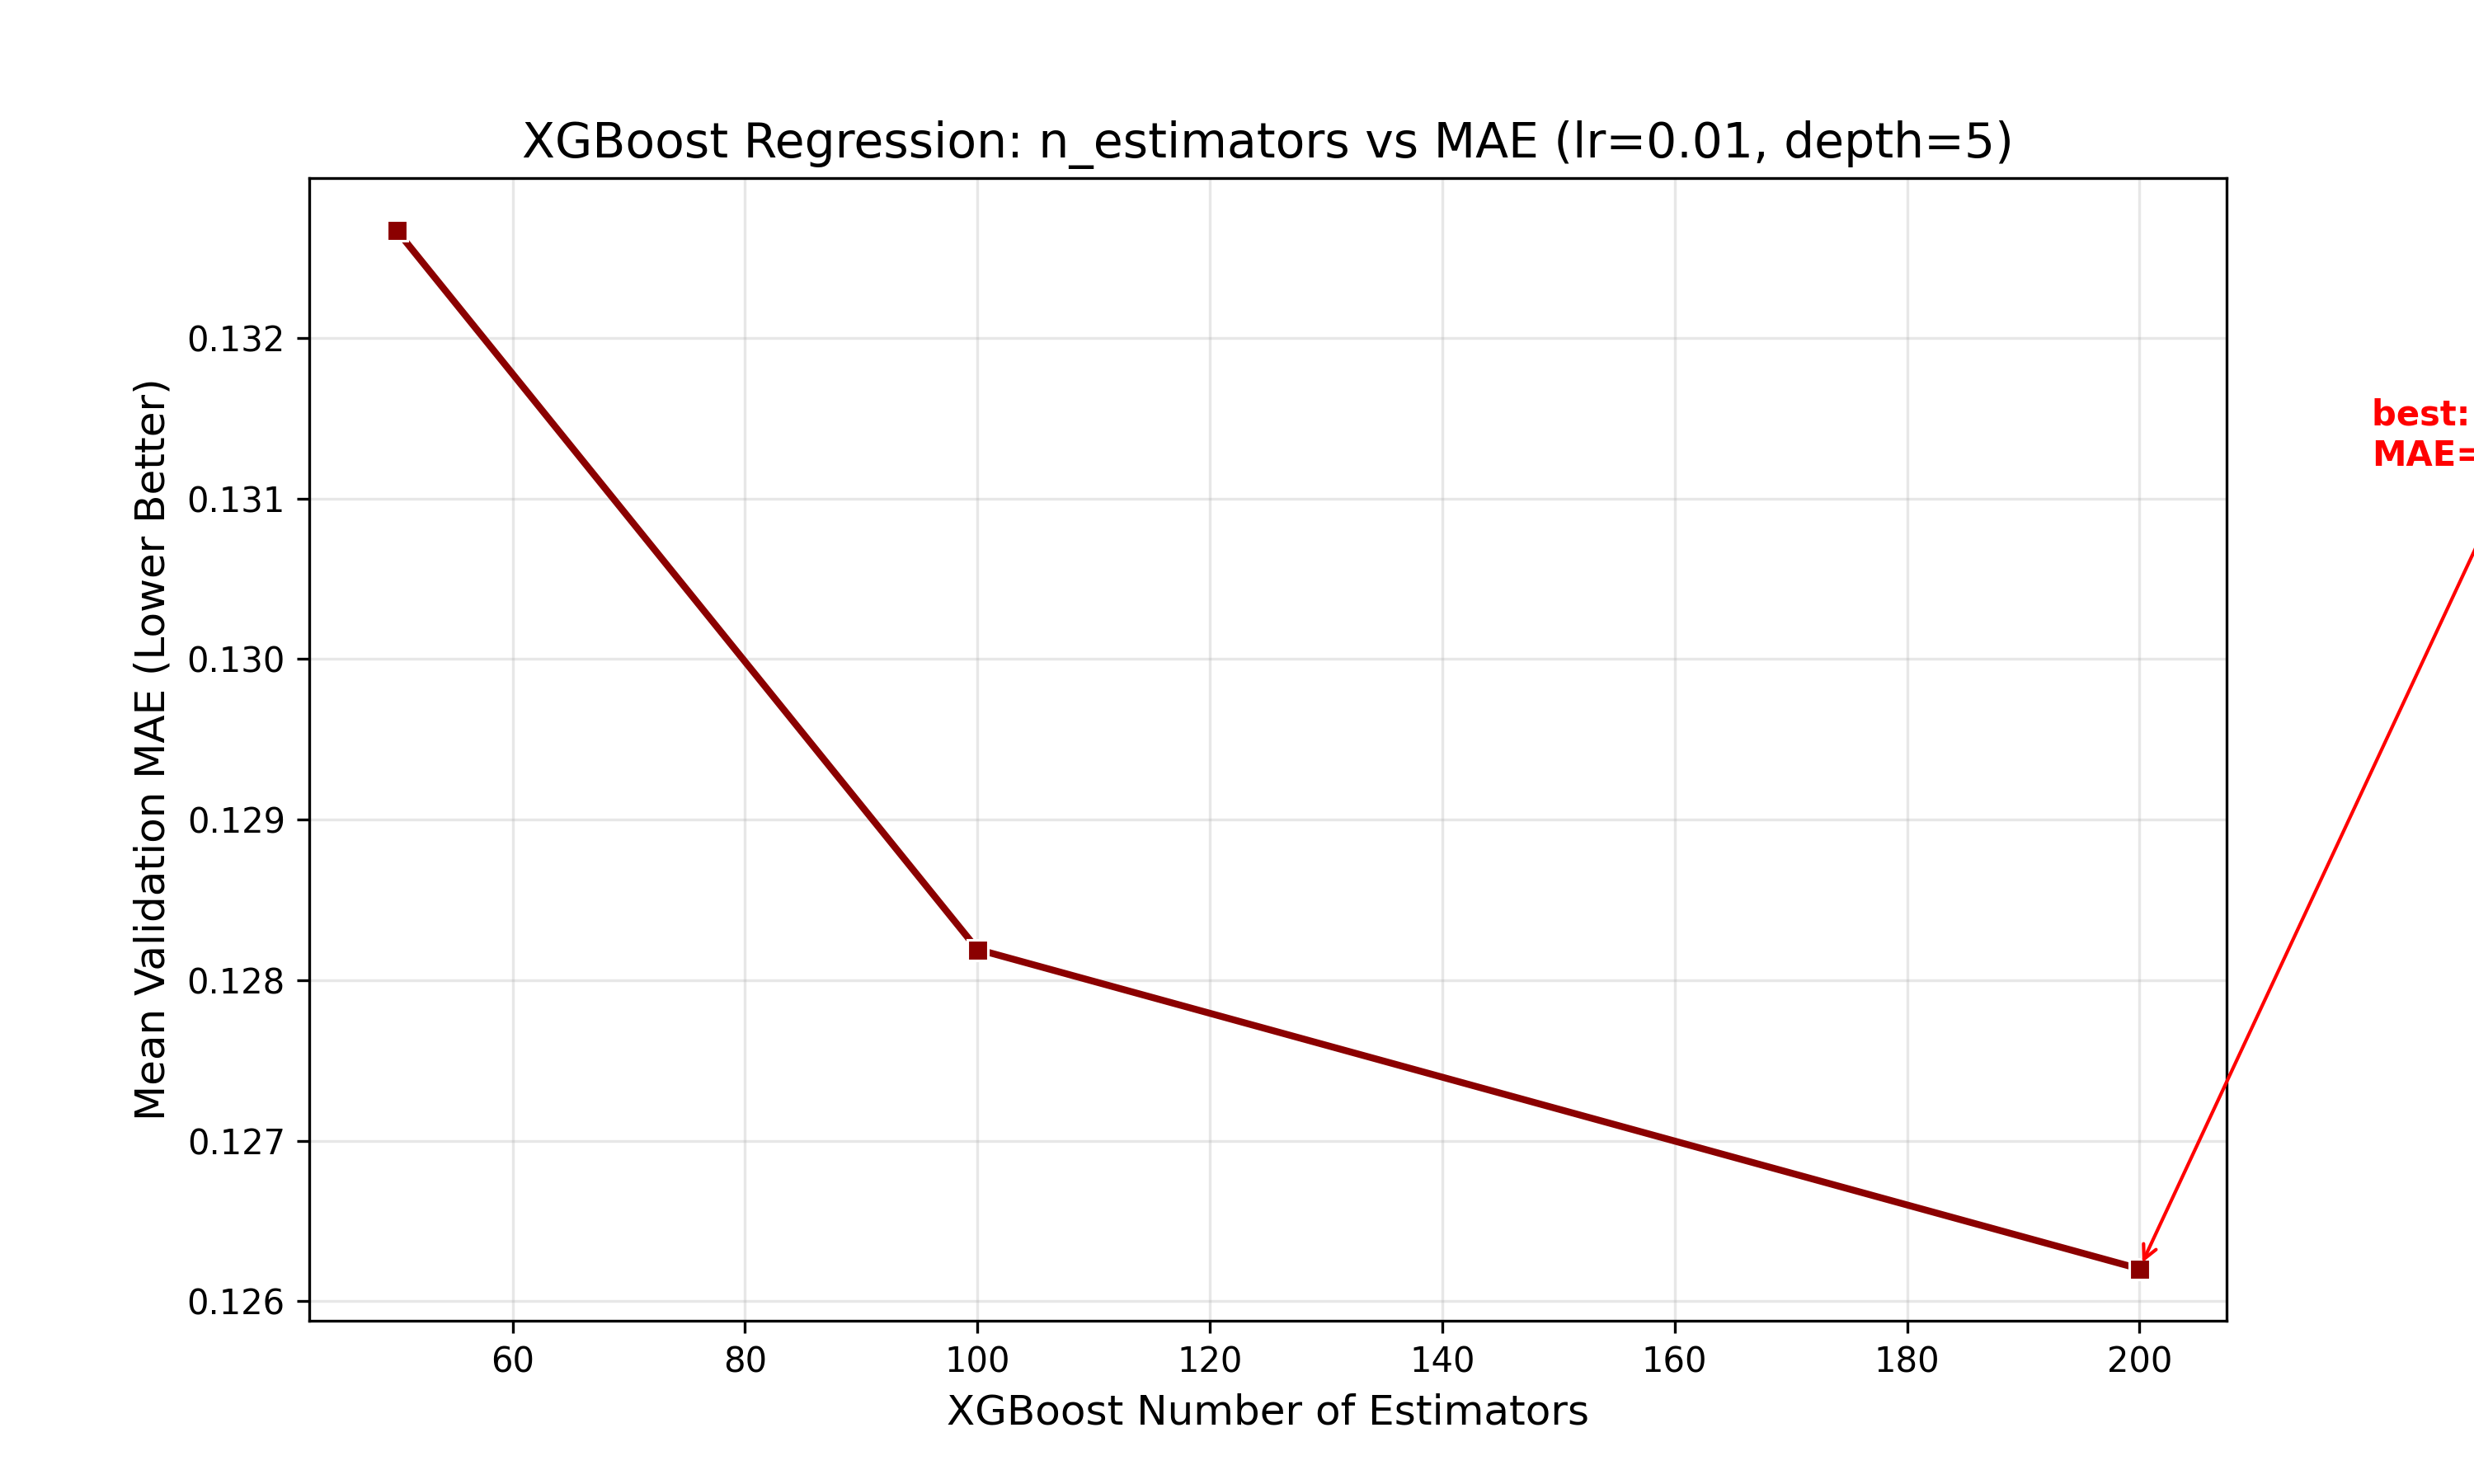

In [ ]:
import os
from IPython.display import display, Image

def display_all_impact_plots(base_dirs):
    keywords = ['impact', 'heatmap', 'alpha']
    # The kernel state shows some files are in /content/ with names like 'tfidf_resultrf_reg...'
    # while others are inside the result folders.
    for base_dir in base_dirs:
        parent = os.path.dirname(base_dir)
        folder_name = os.path.basename(base_dir)

        print(f"\n--- Searching for Impact Plots related to: {folder_name} ---")

        # 1. Check inside the directory
        if os.path.exists(base_dir):
            inner_files = [os.path.join(base_dir, f) for f in os.listdir(base_dir) if any(k in f.lower() for k in keywords)]
            for f in sorted(inner_files):
                print(f"Displaying from folder: {os.path.basename(f)}")
                display(Image(filename=f, width=600))

        # 2. Check for files in parent named 'tfidf_result...' or 'bow_result...'
        parent_files = [os.path.join(parent, f) for f in os.listdir(parent) if f.startswith(folder_name) and any(k in f.lower() for k in keywords)]
        for f in sorted(parent_files):
            print(f"Displaying from root: {os.path.basename(f)}")
            display(Image(filename=f, width=600))

display_all_impact_plots(['/content/tfidf_result', '/content/bow_result'])


DISPLAYING ALL PLOTS IN: /content/bow_result

File: rf_feature_importance.png


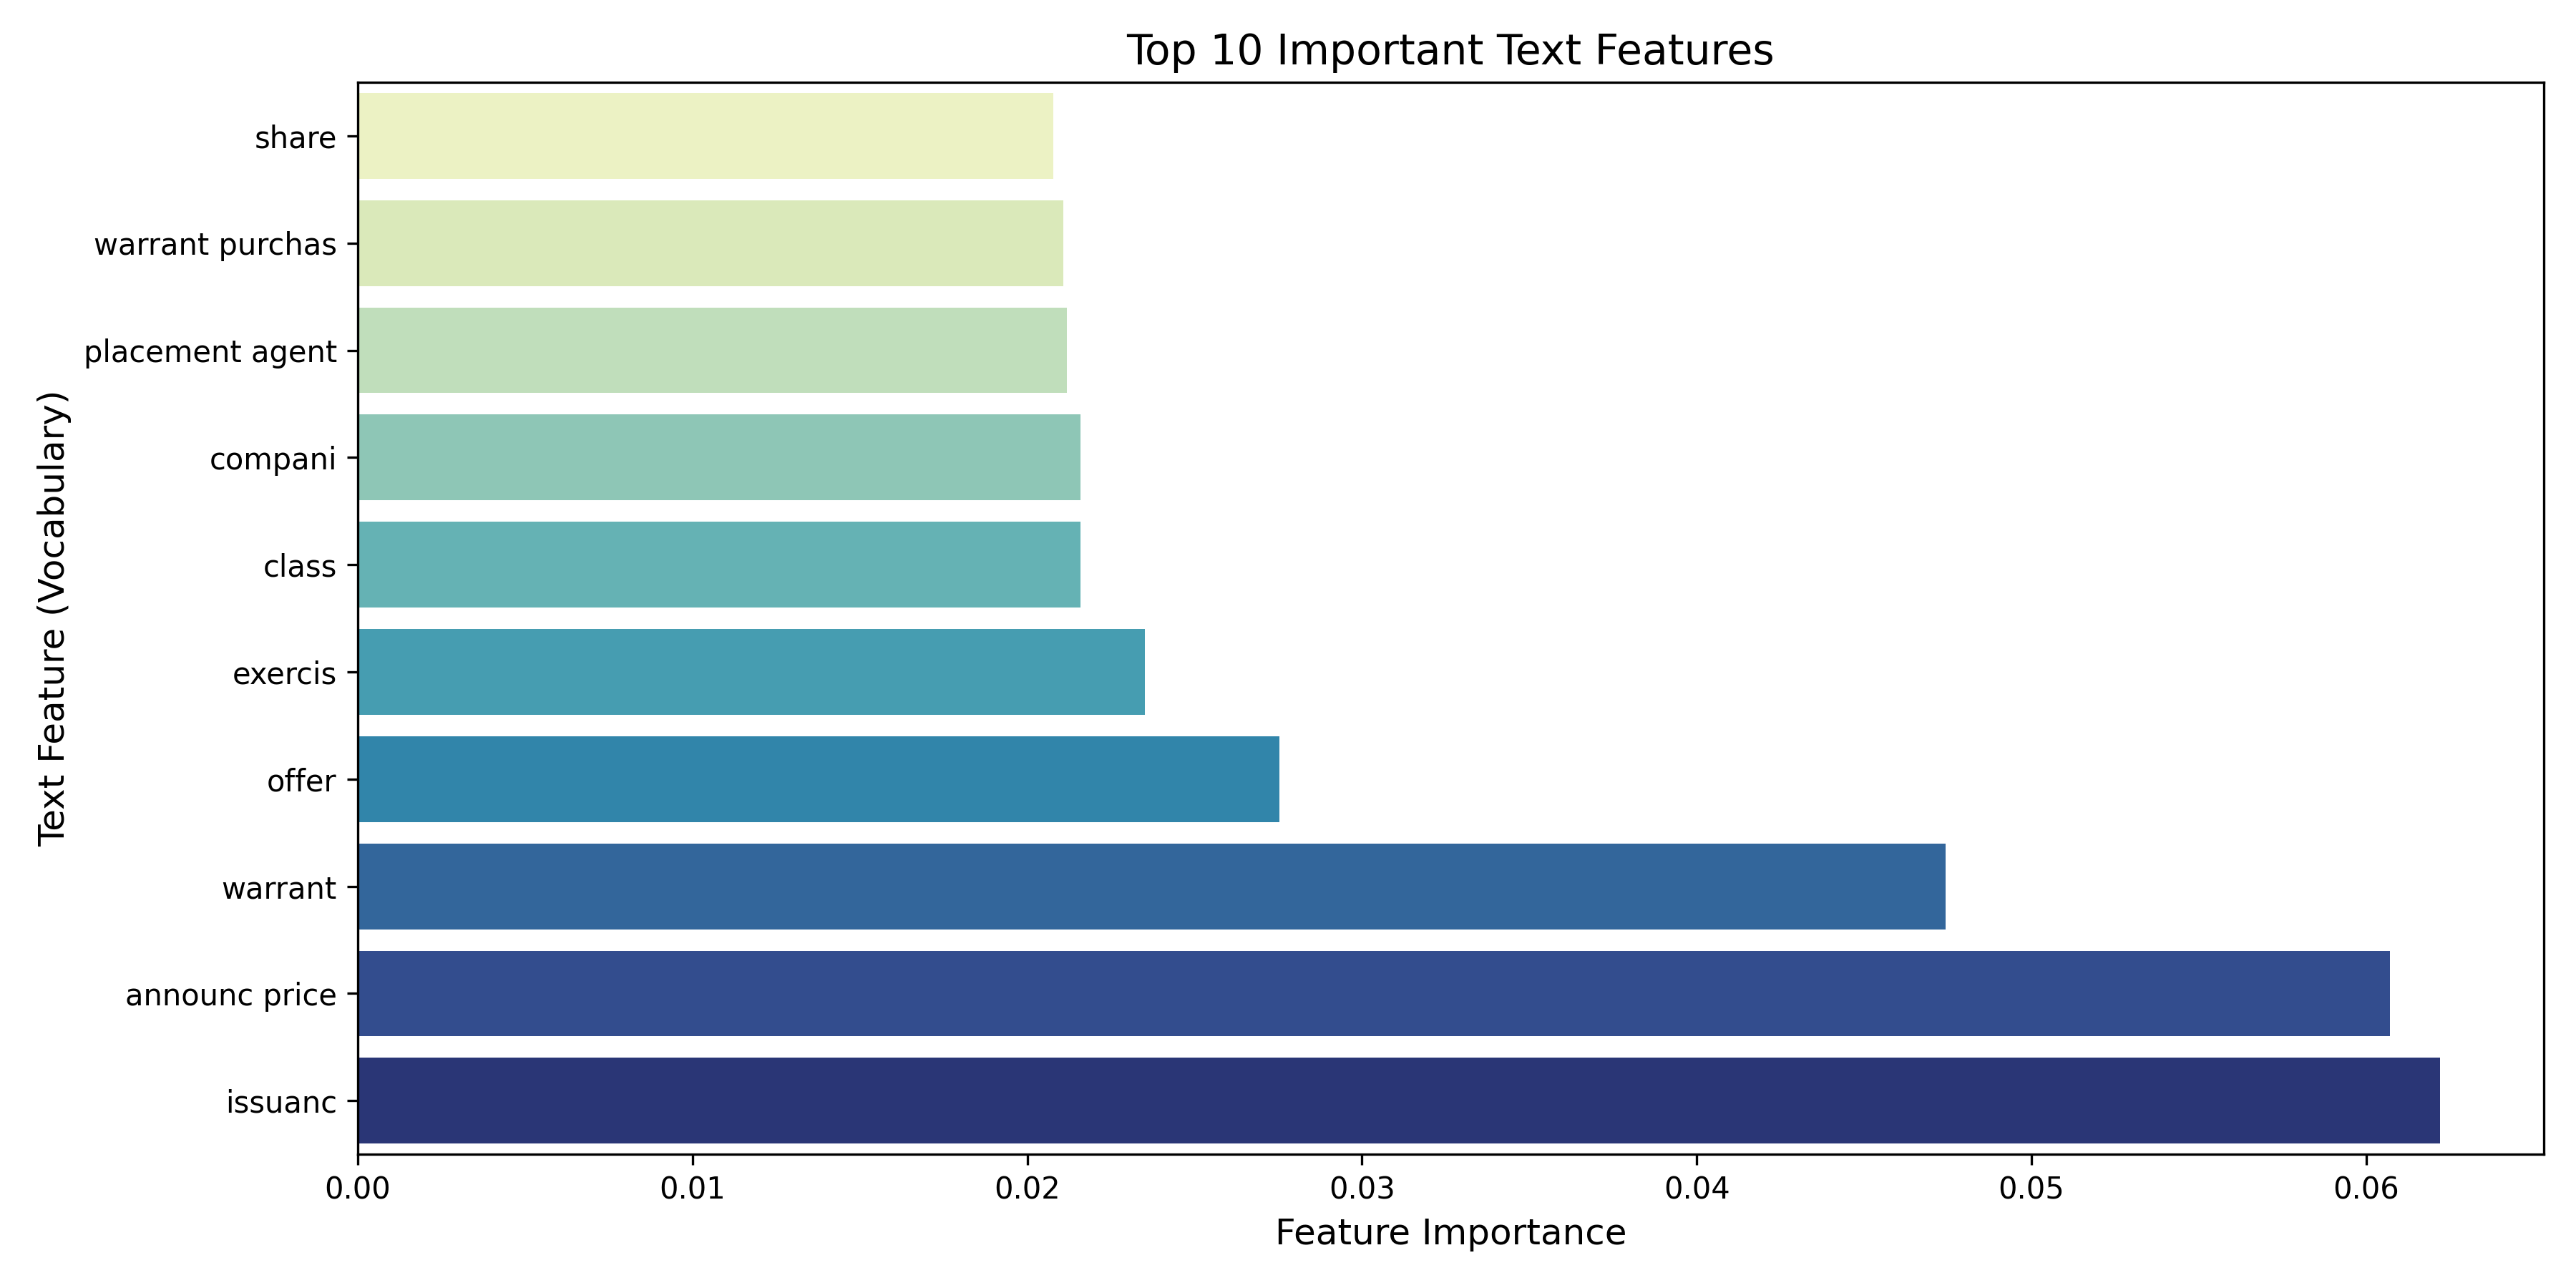


File: xgb_feature_importance.png


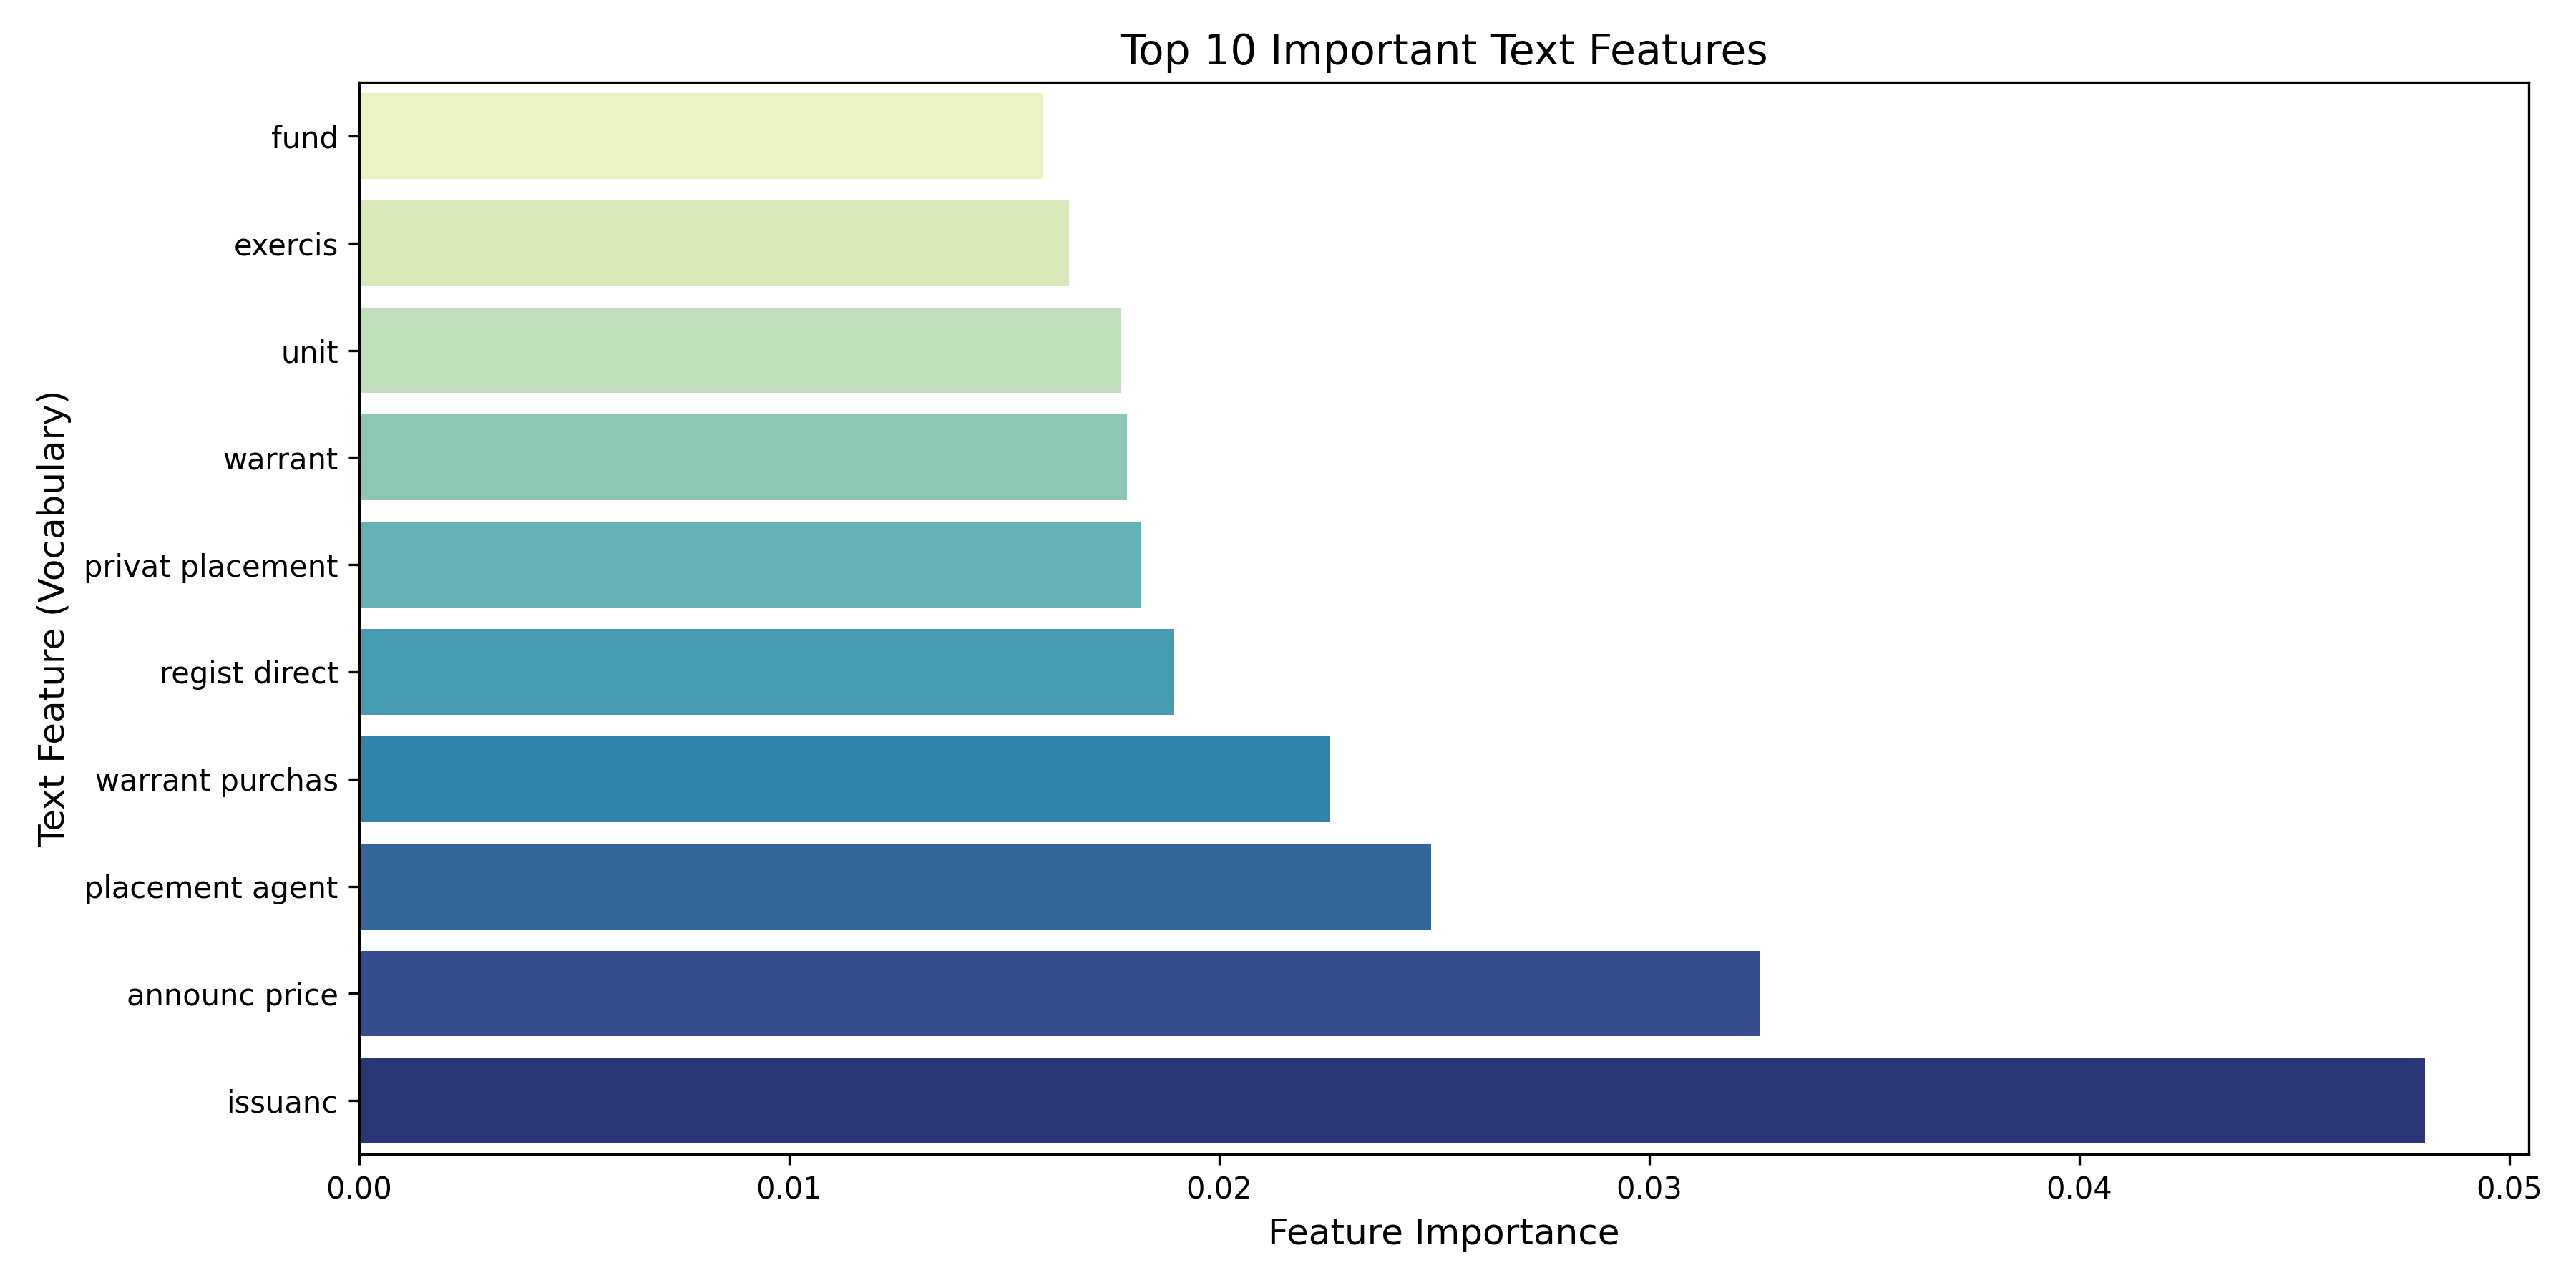

In [ ]:
import os
from IPython.display import display, Image

# Cell 2: BoW Results
# (Shared display function from the previous cell)
display_folder_plots('/content/bow_result')